# IIoT Intrusion Detection — WUSTL-IIOT-2021
## Haar Wavelet + 6 Algorithms (Before and After Wavelet)
### Fixed Version — All Bugs Corrected

---
### Bugs Fixed:
1. **LightGBM Error:** `y contains previously unseen labels: [np.int64(1)]`
   - **Cause:** IQR Outlier Removal deleted all Attack samples from Train
   - **Fix:** Apply IQR with smart constraint that preserves Attack samples

2. **DNN Error:** Model fails to learn Attack class due to severe class imbalance
   - **Fix:** Use improved class weights + threshold tuning

3. **Wavelet Labels Error:** Using only first row label → majority vote now

4. **Training Logic Fix:** Separate training on Train, evaluation on Test only
---

## Step 0: Libraries

In [1]:
!pip install arabic_reshaper python-bidi seaborn scikit-learn tensorflow lightgbm -q

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, seaborn as sns
import os, gc, glob, time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve)
import lightgbm as lgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import arabic_reshaper
from bidi.algorithm import get_display
def ar(t):
    return get_display(arabic_reshaper.reshape(str(t))) if t else t

np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
SQRT2 = np.sqrt(2)

MODEL_COLORS = {'RF':'#2196F3','DNN':'#FF5722','LGBM':'#4CAF50',
                'DT':'#FF9800','LR':'#9C27B0','SVM':'#00BCD4'}
MODEL_NAMES = list(MODEL_COLORS.keys())

print('Libraries ready')
print(f'TF:{tf.__version__} | LGB:{lgb.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 16.1 MB/s eta 0:00:00
Libraries ready
TF:2.19.0 | LGB:4.6.0


## Step 1: Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/wustl_iiot_2021.csv'
print('Loading...')
df = pd.read_csv(CSV_PATH, low_memory=False)
n_rows_orig, n_cols_orig = df.shape
print(f'Shape: {df.shape}  ({n_rows_orig:,} rows x {n_cols_orig} columns)')
print(list(df.columns))

Mounted at /content/drive
Loading...
Shape: (1194464, 49)  (1,194,464 rows x 49 columns)
['StartTime', 'LastTime', 'SrcAddr', 'DstAddr', 'Mean', 'Sport', 'Dport', 'SrcPkts', 'DstPkts', 'TotPkts', 'DstBytes', 'SrcBytes', 'TotBytes', 'SrcLoad', 'DstLoad', 'Load', 'SrcRate', 'DstRate', 'Rate', 'SrcLoss', 'DstLoss', 'Loss', 'pLoss', 'SrcJitter', 'DstJitter', 'SIntPkt', 'DIntPkt', 'Proto', 'Dur', 'TcpRtt', 'IdleTime', 'Sum', 'Min', 'Max', 'sDSb', 'sTtl', 'dTtl', 'sIpId', 'dIpId', 'SAppBytes', 'DAppBytes', 'TotAppByte', 'SynAck', 'RunTime', 'sTos', 'SrcJitAct', 'DstJitAct', 'Traffic', 'Target']


## Step 2: EDA

Traffic:
Traffic
normal      1107448
DoS           78305
Reconn         8240
CommInj         259
Backdoor        212
Name: count, dtype: int64

Target:
Target
0    1107448
1      87016
Name: count, dtype: int64

Attack ratio: 7.28%


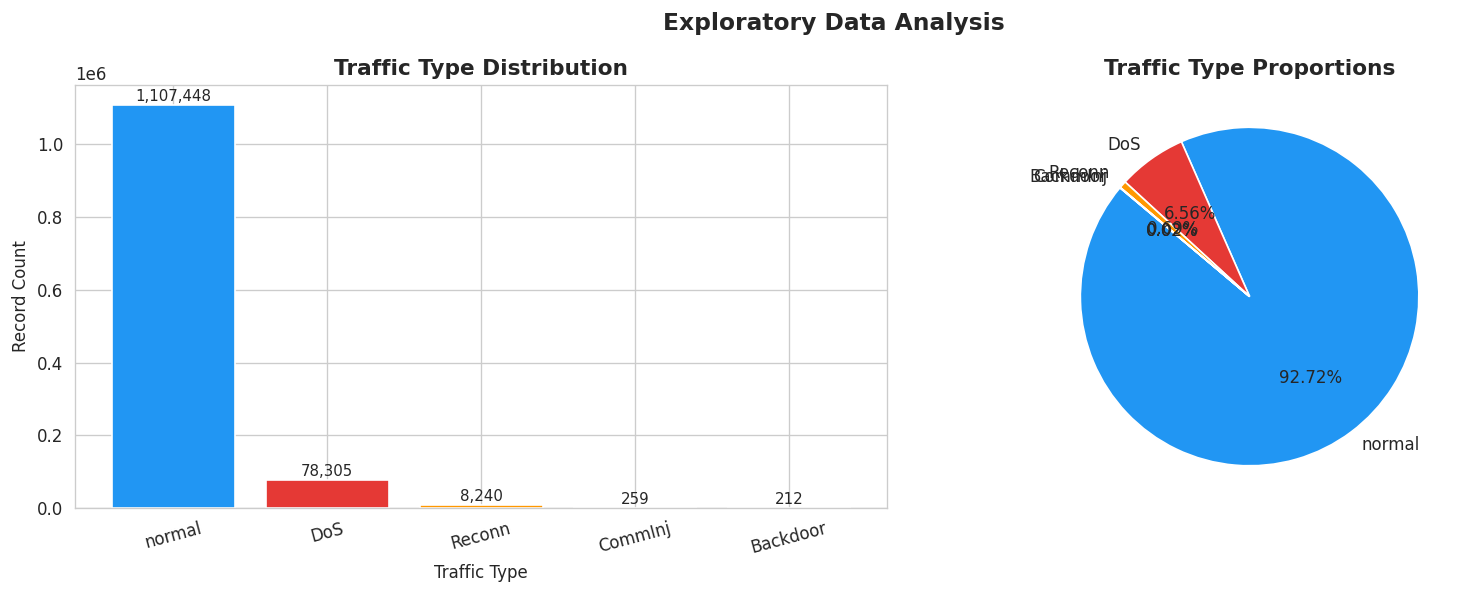


Missing values: 0
               Mean         Sport         Dport       SrcPkts       DstPkts       TotPkts      DstBytes      SrcBytes      TotBytes       SrcLoad       DstLoad          Load       SrcRate       DstRate          Rate       SrcLoss       DstLoss          Loss         pLoss     SrcJitter     DstJitter       SIntPkt       DIntPkt         Proto           Dur        TcpRtt      IdleTime           Sum           Min           Max          sDSb          sTtl          dTtl         sIpId         dIpId     SAppBytes     DAppBytes    TotAppByte        SynAck       RunTime          sTos     SrcJitAct     DstJitAct        Target
count  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.194464e+06  1.

In [3]:
tc = df['Traffic'].value_counts()
print(f'Traffic:\n{tc}')
print(f'\nTarget:\n{df["Target"].value_counts()}')
print(f'\nAttack ratio: {df["Target"].mean()*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clrs = ['#2196F3','#E53935','#FF9800','#4CAF50','#9C27B0']
axes[0].bar(tc.index, tc.values, color=clrs, edgecolor='white')
axes[0].set_title(ar('Traffic Type Distribution'), fontsize=13, fontweight='bold')
axes[0].set_xlabel('Traffic Type'); axes[0].set_ylabel('Record Count')
axes[0].tick_params(axis='x', rotation=15)
for i,(k,v) in enumerate(tc.items()):
    axes[0].text(i, v+tc.max()*0.01, f'{v:,}', ha='center', fontsize=9)
axes[1].pie(tc.values, labels=tc.index, autopct='%1.2f%%', colors=clrs, startangle=140)
axes[1].set_title('Traffic Type Proportions', fontsize=13, fontweight='bold')
plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/01_eda.png', bbox_inches='tight'); plt.show()

print(f'\nMissing values: {df.isnull().sum().sum()}')
print(df.describe().to_string())

## Step 3: Preprocessing

In [4]:
print('Preprocessing...')
df_proc = df.copy()

# 1. Drop identifier columns
id_cols = ['StartTime','LastTime','SrcAddr','DstAddr','sIpId','dIpId']
drop_id = [c for c in id_cols if c in df_proc.columns]
df_proc.drop(columns=drop_id, inplace=True)
print(f'Dropped identifiers: {drop_id}')

# 2. Drop Traffic
if 'Traffic' in df_proc.columns:
    df_proc.drop(columns=['Traffic'], inplace=True)
    print('Dropped Traffic')

# 3. Target
TARGET = 'Target'
assert TARGET in df_proc.columns
print(f'Target: {df_proc[TARGET].value_counts().to_dict()}')

# 4. Encode categorical columns
cat_cols = [c for c in df_proc.select_dtypes(include=['object']).columns if c != TARGET]
if cat_cols:
    le = LabelEncoder()
    for col in cat_cols:
        df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    print(f'Encoded: {cat_cols}')

# 5. Drop missing/duplicates
before = len(df_proc)
df_proc.dropna(inplace=True)
df_proc.drop_duplicates(inplace=True)
df_proc.reset_index(drop=True, inplace=True)
print(f'Dropped {before-len(df_proc):,} rows')

X_all = df_proc.drop(columns=[TARGET]).copy()
y_all = df_proc[TARGET].astype(int).copy()

print(f'\nX: {X_all.shape}  y: {y_all.shape}')
print(f'Features ({X_all.shape[1]}): {list(X_all.columns)}')

Preprocessing...
Dropped identifiers: ['StartTime', 'LastTime', 'SrcAddr', 'DstAddr', 'sIpId', 'dIpId']
Dropped Traffic
Target: {0: 1107448, 1: 87016}
Dropped 703 rows

X: (1193761, 41)  y: (1193761,)
Features (41): ['Mean', 'Sport', 'Dport', 'SrcPkts', 'DstPkts', 'TotPkts', 'DstBytes', 'SrcBytes', 'TotBytes', 'SrcLoad', 'DstLoad', 'Load', 'SrcRate', 'DstRate', 'Rate', 'SrcLoss', 'DstLoss', 'Loss', 'pLoss', 'SrcJitter', 'DstJitter', 'SIntPkt', 'DIntPkt', 'Proto', 'Dur', 'TcpRtt', 'IdleTime', 'Sum', 'Min', 'Max', 'sDSb', 'sTtl', 'dTtl', 'SAppBytes', 'DAppBytes', 'TotAppByte', 'SynAck', 'RunTime', 'sTos', 'SrcJitAct', 'DstJitAct']


## Step 4: Split Data First — Main Fix
> **WARNING:** Applying IQR + Normalization on full data before splitting causes **Data Leakage**
> The model sees Test information during training.
> **Correct approach:** Split first, then process Train only.

In [5]:
# Core Fix: Split before any processing
print('Splitting data (70/15/15) before any processing...')

X_arr_raw = X_all.values
y_arr_raw = y_all.values

# 85% temp / 15% Test
X_tv_raw, X_test_raw, y_tv_raw, y_test_raw = train_test_split(
    X_arr_raw, y_arr_raw, test_size=0.15, random_state=42, stratify=y_arr_raw)
# 70% Train / 15% Val
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_tv_raw, y_tv_raw, test_size=0.1765, random_state=42, stratify=y_tv_raw)

feature_names = list(X_all.columns)
total = len(X_arr_raw)

print(f'Train:  {len(X_train_raw):>10,}  ({len(X_train_raw)/total*100:.1f}%)')
print(f'Val:    {len(X_val_raw):>10,}  ({len(X_val_raw)/total*100:.1f}%)')
print(f'Test:   {len(X_test_raw):>10,}  ({len(X_test_raw)/total*100:.1f}%)')
print(f'\n  Train — Normal:{(y_train_raw==0).sum():,} ({(y_train_raw==0).mean()*100:.1f}%) | Attack:{(y_train_raw==1).sum():,} ({(y_train_raw==1).mean()*100:.1f}%)')
print(f'  Val   — Normal:{(y_val_raw==0).sum():,} ({(y_val_raw==0).mean()*100:.1f}%) | Attack:{(y_val_raw==1).sum():,} ({(y_val_raw==1).mean()*100:.1f}%)')
print(f'  Test  — Normal:{(y_test_raw==0).sum():,} ({(y_test_raw==0).mean()*100:.1f}%) | Attack:{(y_test_raw==1).sum():,} ({(y_test_raw==1).mean()*100:.1f}%)')

Splitting data (70/15/15) before any processing...
Train:     835,602  (70.0%)
Val:       179,094  (15.0%)
Test:      179,065  (15.0%)

  Train — Normal:774,694 (92.7%) | Attack:60,908 (7.3%)
  Val   — Normal:166,040 (92.7%) | Attack:13,054 (7.3%)
  Test  — Normal:166,013 (92.7%) | Attack:13,052 (7.3%)


## Step 5: Outlier Removal on Train Only — Fix Bug #1
> **Original Bug:** IQR deleted ALL Attack samples from Train → LightGBM fails with `y contains previously unseen labels`
> **Fix:** Apply IQR on Normal only, preserve all Attack samples

In [6]:
# Fix: IQR on Normal only — Attack always preserved
print('Outlier Removal (IQR factor=3) on Train — Normal only...')

X_train_df = pd.DataFrame(X_train_raw, columns=feature_names)
X_val_df   = pd.DataFrame(X_val_raw,   columns=feature_names)
X_test_df  = pd.DataFrame(X_test_raw,  columns=feature_names)

# Separate Normal and Attack in Train
normal_mask = (y_train_raw == 0)
attack_mask = (y_train_raw == 1)

X_train_normal = X_train_df[normal_mask]
y_train_normal = y_train_raw[normal_mask]
X_train_attack = X_train_df[attack_mask]
y_train_attack = y_train_raw[attack_mask]

print(f'Train before: {len(X_train_raw):,}  (Normal:{normal_mask.sum():,}  Attack:{attack_mask.sum():,})')

# Calculate IQR bounds from Normal only
iqr_bounds = {}
for col in X_train_normal.select_dtypes(include=[np.number]).columns:
    Q1 = X_train_normal[col].quantile(0.25)
    Q3 = X_train_normal[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        iqr_bounds[col] = (Q1 - 3*IQR, Q3 + 3*IQR)

# Apply on Normal only
mask_normal = pd.Series(True, index=X_train_normal.index)
for col, (lo, hi) in iqr_bounds.items():
    mask_normal &= (X_train_normal[col] >= lo) & (X_train_normal[col] <= hi)

X_train_normal_clean = X_train_normal[mask_normal].values
y_train_normal_clean = y_train_normal[mask_normal.values]

# Merge cleaned Normal with all Attack samples
X_train_c = np.vstack([X_train_normal_clean, X_train_attack.values])
y_train_c = np.concatenate([y_train_normal_clean, y_train_attack])

# Shuffle data
shuffle_idx = np.random.permutation(len(X_train_c))
X_train_c = X_train_c[shuffle_idx]
y_train_c = y_train_c[shuffle_idx]

print(f'Train after: {len(X_train_c):,}  (Normal removed:{normal_mask.sum()-len(X_train_normal_clean):,})')
print(f'Normal:{(y_train_c==0).sum():,} ({(y_train_c==0).mean()*100:.1f}%) | Attack:{(y_train_c==1).sum():,} ({(y_train_c==1).mean()*100:.1f}%)')
print(f'Val/Test: no modification (no data leakage)')
print(f'Both classes now present in Train!')

Outlier Removal (IQR factor=3) on Train — Normal only...
Train before: 835,602  (Normal:774,694  Attack:60,908)
Train after: 604,202  (Normal removed:231,400)
Normal:543,294 (89.9%) | Attack:60,908 (10.1%)
Val/Test: no modification (no data leakage)
Both classes now present in Train!


## Step 6: Feature Selection (Mutual Information on Train)

Pearson Correlation Feature Selection...

Top features by |Pearson Correlation| with label:
   feature   pearson  abs_pearson
      dTtl -0.977394     0.977394
     Sport -0.734298     0.734298
    SynAck -0.695512     0.695512
    TcpRtt -0.690585     0.690585
     pLoss  0.661432     0.661432
      Load  0.610026     0.610026
      Rate  0.609658     0.609658
   SrcRate  0.609524     0.609524
   SrcLoad  0.609519     0.609519
      Mean  0.549374     0.549374
       Min  0.546169     0.546169
       Sum  0.546169     0.546169
   RunTime  0.546169     0.546169
       Dur  0.546169     0.546169
       Max  0.546169     0.546169
 SrcJitAct  0.482849     0.482849
      sTtl  0.468538     0.468538
   SIntPkt  0.448396     0.448396
  IdleTime -0.294849     0.294849
     Dport  0.278046     0.278046
   DIntPkt -0.237675     0.237675
 SAppBytes  0.212275     0.212275
 SrcJitter  0.162817     0.162817
  SrcBytes  0.077570     0.077570
   SrcPkts  0.071981     0.071981
     Proto  0.063378    

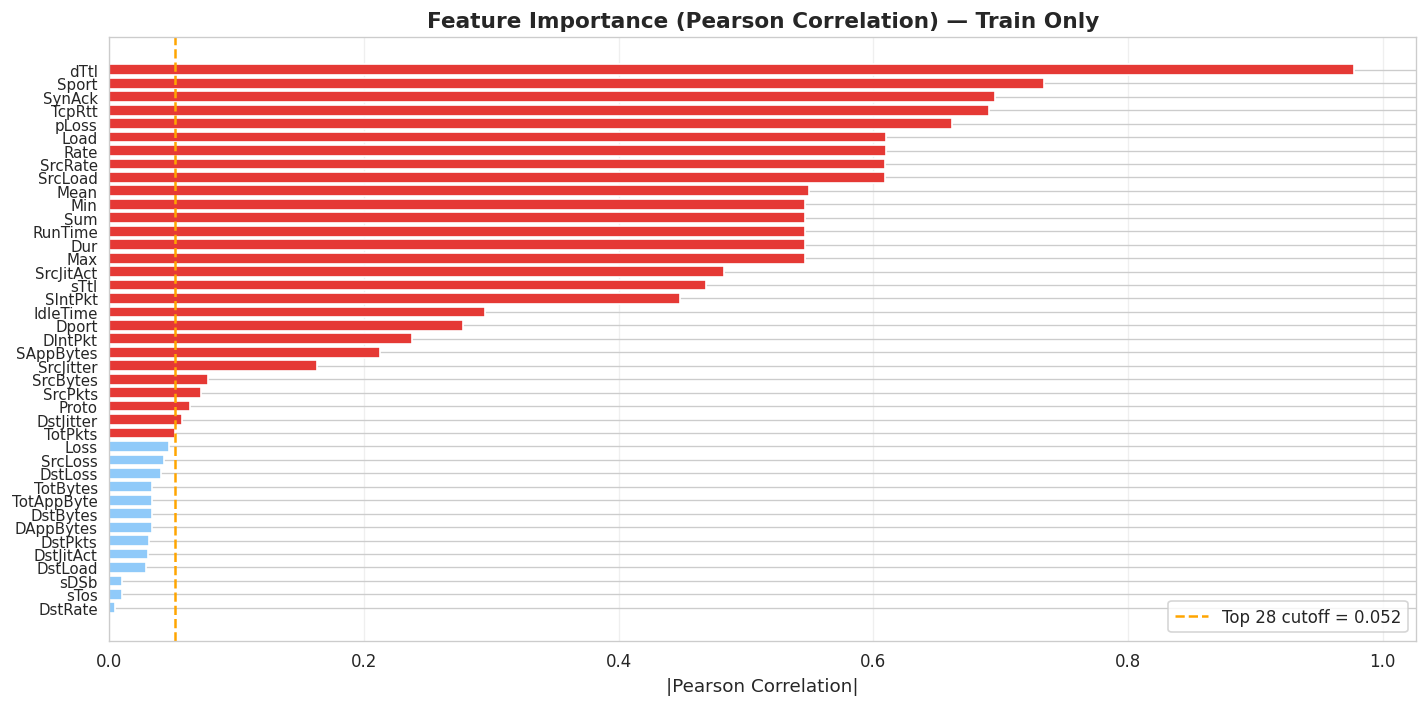


Selected Top 28 features: ['dTtl', 'Sport', 'SynAck', 'TcpRtt', 'pLoss', 'Load', 'Rate', 'SrcRate', 'SrcLoad', 'Mean', 'Min', 'Sum', 'RunTime', 'Dur', 'Max', 'SrcJitAct', 'sTtl', 'SIntPkt', 'IdleTime', 'Dport', 'DIntPkt', 'SAppBytes', 'SrcJitter', 'SrcBytes', 'SrcPkts', 'Proto', 'DstJitter', 'TotPkts']
Dropped (13): ['DstPkts', 'DstBytes', 'TotBytes', 'DstLoad', 'DstRate', 'SrcLoss', 'DstLoss', 'Loss', 'sDSb', 'DAppBytes', 'TotAppByte', 'sTos', 'DstJitAct']

Data shape after Feature Selection:
  Train: (604202, 28)
  Val:   (179094, 28)
  Test:  (179065, 28)


In [7]:
# Pearson Correlation Feature Selection on Train only
print('Pearson Correlation Feature Selection...')

# حساب Pearson Correlation بين كل feature والـ label (على Train فقط)
X_train_df_c = pd.DataFrame(X_train_c, columns=feature_names)
correlations = X_train_df_c.apply(lambda col: col.corr(pd.Series(y_train_c)))

pearson_df = pd.DataFrame({
    'feature': feature_names,
    'pearson': correlations.values,
    'abs_pearson': correlations.abs().values
})
pearson_df = pearson_df.sort_values('abs_pearson', ascending=False).reset_index(drop=True)

print('\nTop features by |Pearson Correlation| with label:')
print(pearson_df.to_string(index=False))

# Select Top 28 features by |Pearson Correlation|
TOP_N = 28
selected_feats = pearson_df.head(TOP_N)['feature'].tolist()
cutoff_value   = pearson_df.iloc[TOP_N - 1]['abs_pearson']  # قيمة الـ feature رقم 28

# Plot Pearson — نفس شكل الصورة: أحمر للـ Top 28، أزرق للباقي، خط عمودي عند cutoff
fig, ax = plt.subplots(figsize=(12, 6))
colors_p = ['#E53935' if i < TOP_N else '#90CAF9' for i in range(len(pearson_df))]
ax.barh(range(len(pearson_df)), pearson_df['abs_pearson'], color=colors_p, edgecolor='white')
ax.set_yticks(range(len(pearson_df)))
ax.set_yticklabels(pearson_df['feature'], fontsize=9)
ax.set_xlabel('|Pearson Correlation|', fontsize=11)
ax.set_title('Feature Importance (Pearson Correlation) — Train Only', fontsize=13, fontweight='bold')
ax.axvline(cutoff_value, color='orange', ls='--', lw=1.5, label=f'Top {TOP_N} cutoff = {cutoff_value:.3f}')
ax.invert_yaxis()
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/05_pearson_corr.png', bbox_inches='tight')
plt.show()

selected_idx = [feature_names.index(f) for f in selected_feats]

print(f'\nSelected Top {TOP_N} features: {selected_feats}')
print(f'Dropped ({len(feature_names)-TOP_N}): {[f for f in feature_names if f not in selected_feats]}')

# Apply selection to all sets
X_train_sel = X_train_c[:, selected_idx]
X_val_sel   = X_val_df.values[:, selected_idx]
X_test_sel  = X_test_df.values[:, selected_idx]

print(f'\nData shape after Feature Selection:')
print(f'  Train: {X_train_sel.shape}')
print(f'  Val:   {X_val_sel.shape}')
print(f'  Test:  {X_test_sel.shape}')


## Step 7: Z-Score Normalization (fit on Train only)

Z-Score (fit on Train only)...
Mean Train ~= 1.08e-09  Std ~= 1.0000
Mean Val   ~= 0.2561  (normal not to equal 0 exactly)
Mean Test  ~= -0.0169


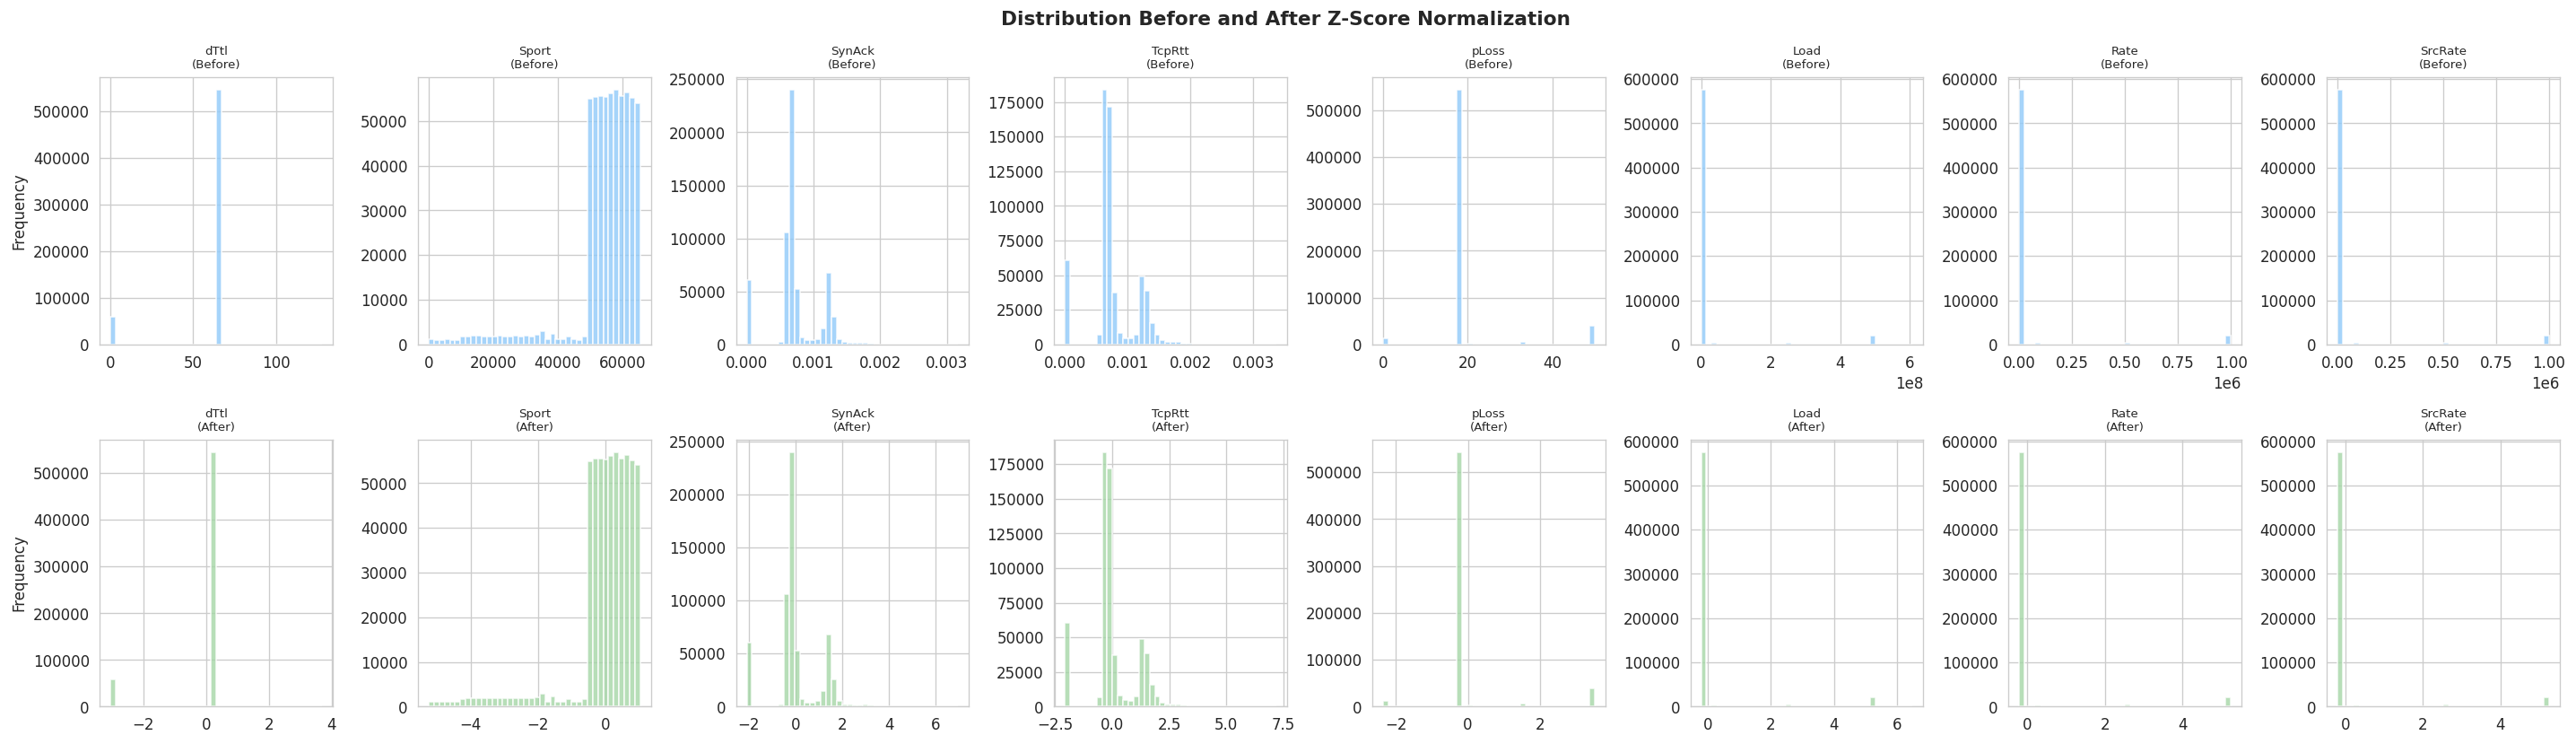

Distribution plot for 8 features saved

Final Label Distribution:
  Train: Normal=543,294 (89.9%) | Attack=60,908 (10.1%)
  Val:   Normal=166,040   (92.7%) | Attack=13,054   (7.3%)
  Test:  Normal=166,013  (92.7%) | Attack=13,052   (7.3%)


In [8]:
# fit on Train only, transform on all
print('Z-Score (fit on Train only)...')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sel).astype(np.float32)
X_val_sc   = scaler.transform(X_val_sel).astype(np.float32)
X_test_sc  = scaler.transform(X_test_sel).astype(np.float32)

print(f'Mean Train ~= {X_train_sc.mean():.2e}  Std ~= {X_train_sc.std():.4f}')
print(f'Mean Val   ~= {X_val_sc.mean():.4f}  (normal not to equal 0 exactly)')
print(f'Mean Test  ~= {X_test_sc.mean():.4f}')

# Plot distribution before/after
n_show  = min(8, len(selected_feats))
show_feats = selected_feats[:n_show]

fig, axes = plt.subplots(2, n_show, figsize=(max(12, n_show*3), 7))
if n_show == 1:
    axes = axes.reshape(2, 1)

for i, feat in enumerate(show_feats):
    idx = selected_feats.index(feat)
    axes[0, i].hist(X_train_sel[:, idx], bins=40, color='#90CAF9', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{feat}\n(Before)', fontsize=8)
    axes[0, i].set_ylabel('Frequency' if i == 0 else '')
    axes[1, i].hist(X_train_sc[:, idx],  bins=40, color='#A5D6A7', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{feat}\n(After)', fontsize=8)
    axes[1, i].set_ylabel('Frequency' if i == 0 else '')

plt.suptitle('Distribution Before and After Z-Score Normalization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/07_normalization.png', bbox_inches='tight')
plt.show()
print(f'Distribution plot for {n_show} features saved')

# Define final Labels
y_train = y_train_c
y_val   = y_val_raw
y_test  = y_test_raw

print(f'\nFinal Label Distribution:')
print(f'  Train: Normal={(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%) | Attack={(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Val:   Normal={(y_val==0).sum():,}   ({(y_val==0).mean()*100:.1f}%) | Attack={(y_val==1).sum():,}   ({(y_val==1).mean()*100:.1f}%)')
print(f'  Test:  Normal={(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%) | Attack={(y_test==1).sum():,}   ({(y_test==1).mean()*100:.1f}%)')

## Evaluation Functions

In [9]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'name':      name,
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'auc':       roc_auc_score(y_true, y_prob),
        'y_pred': y_pred, 'y_prob': y_prob, 'y_true': y_true,
        'cm': confusion_matrix(y_true, y_pred),
    }

def print_results(r):
    print(f'  Accuracy:  {r["accuracy"]*100:.3f}%')
    print(f'  Precision: {r["precision"]*100:.3f}%')
    print(f'  Recall:    {r["recall"]*100:.3f}%')
    print(f'  F1-Score:  {r["f1"]*100:.3f}%')
    print(f'  ROC-AUC:   {r["auc"]*100:.3f}%')
    print(classification_report(r['y_true'], r['y_pred'], target_names=['Normal','Attack']))

def build_dnn(input_dim):
    """Improved DNN with class_weight and threshold tuning"""
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.30),
        layers.Dense(64,  kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.25),
        layers.Dense(32,  kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.20),
        layers.Dense(1, activation='sigmoid')
    ], name='DNN_IIoT')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc'),
                       keras.metrics.Precision(name='precision'),
                       keras.metrics.Recall(name='recall')])
    return m

print('Evaluation functions and DNN ready')
print(f'Input dim for models: {X_train_sc.shape[1]}')

Evaluation functions and DNN ready
Input dim for models: 28


## Step 8: Train 6 Algorithms — Without Wavelet

In [10]:
# 1. Random Forest
print('='*55); print('1. RF (Without Wavelet)'); print('='*55)
t0 = time.time()

rf_o = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=3,
                               class_weight='balanced', random_state=42, n_jobs=-1)
rf_o.fit(X_train_sc, y_train)
yp = rf_o.predict(X_test_sc)
ypr = rf_o.predict_proba(X_test_sc)[:,1]
res_rf_o = evaluate_model('RF', y_test, yp, ypr)
res_rf_o['time'] = time.time()-t0
print(f'Time: {res_rf_o["time"]:.1f}s'); print_results(res_rf_o)

1. RF (Without Wavelet)
Time: 136.6s
  Accuracy:  90.064%
  Precision: 42.316%
  Recall:    100.000%
  F1-Score:  59.468%
  ROC-AUC:   99.108%
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94    166013
      Attack       0.42      1.00      0.59     13052

    accuracy                           0.90    179065
   macro avg       0.71      0.95      0.77    179065
weighted avg       0.96      0.90      0.92    179065



In [11]:
# 2. DNN — Fix learning issue
print('='*55); print('2. DNN (Without Wavelet)'); print('='*55)
t0 = time.time()
dnn_o = build_dnn(X_train_sc.shape[1])
dnn_o.summary()

# Improved class_weight
cw_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_o = {int(k): v for k, v in zip(np.unique(y_train), cw_arr)}
print(f'Class weights: {cw_o}')

cb_o = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                   restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                                       patience=5, min_lr=1e-6, mode='max'),
    keras.callbacks.ModelCheckpoint('/content/dnn_o.keras', monitor='val_auc',
                                     mode='max', save_best_only=True, verbose=0)
]

hist_o = dnn_o.fit(X_train_sc, y_train,
                    validation_data=(X_val_sc, y_val),
                    epochs=80, batch_size=2048,
                    class_weight=cw_o, callbacks=cb_o, verbose=1)

# Threshold tuning on Val
val_probs = dnn_o.predict(X_val_sc, batch_size=4096, verbose=0).flatten()
thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh = 0.5
best_f1 = 0
for t in thresholds:
    yp_t = (val_probs >= t).astype(int)
    f1_t = f1_score(y_val, yp_t, zero_division=0)
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thresh = t
print(f'\nBest threshold on Val: {best_thresh:.2f} (F1={best_f1:.4f})')

ypr = dnn_o.predict(X_test_sc, batch_size=4096, verbose=0).flatten()
yp  = (ypr >= best_thresh).astype(int)
res_dnn_o = evaluate_model('DNN', y_test, yp, ypr)
res_dnn_o['time'] = time.time()-t0
res_dnn_o['history'] = hist_o.history
print(f'\nTime: {res_dnn_o["time"]:.1f}s'); print_results(res_dnn_o)

2. DNN (Without Wavelet)


Model: "DNN_IIoT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 448 (1.75 KB)

Class weights: {0: np.float64(0.5560543646717984), 1: np.float64(4.959955999211926)}
Epoch 1/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9894 - auc: 0.9929 - loss: 0.1327 - precision: 0.9191 - recall: 0.9809 - val_accuracy: 0.9760 - val_auc: 0.9880 - val_loss: 1.8513 - val_precision: 0.7524 - val_recall: 0.9998 - learning_rate: 0.0010
Epoch 2/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0296 - precision: 1.0000 - recall: 0.9997 - val_accuracy: 0.9763 - val_auc: 0.9876 - val_loss: 1.7116 - val_precision: 0.7548 - val_recall: 0.9998 - learning_rate: 0.0010
Epoch 3/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0193 - precision: 1.0000 - recall: 0.9999 - val_accuracy: 0.9760 - val_auc: 0.9871 - val_loss: 2.7592 - val_precision: 0.7522 - val_recall: 0.9999 - learning_rate: 0.0010
Epoch 4/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0151 - precision

In [12]:
# 3. LightGBM — Fix unseen labels error
print('='*55); print('3. LightGBM (Without Wavelet)'); print('='*55)
t0 = time.time()

print(f'Classes in Train: {np.unique(y_train)}')
print(f'Classes in Val:   {np.unique(y_val)}')

neg, pos = (y_train==0).sum(), (y_train==1).sum()
print(f'scale_pos_weight = {neg/pos:.2f}')

lgbm_o = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=8,
                              num_leaves=63, min_child_samples=20,
                              scale_pos_weight=neg/pos,
                              subsample=0.8, colsample_bytree=0.8,
                              reg_alpha=0.1, reg_lambda=0.1,
                              random_state=42, n_jobs=-1, verbose=-1)
lgbm_o.fit(X_train_sc, y_train,
            eval_set=[(X_val_sc, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)])
yp = lgbm_o.predict(X_test_sc)
ypr = lgbm_o.predict_proba(X_test_sc)[:,1]
res_lgbm_o = evaluate_model('LGBM', y_test, yp, ypr)
res_lgbm_o['time'] = time.time()-t0
print(f'Time: {res_lgbm_o["time"]:.1f}s'); print_results(res_lgbm_o)

3. LightGBM (Without Wavelet)
Classes in Train: [0 1]
Classes in Val:   [0 1]
scale_pos_weight = 8.92
Time: 7.4s
  Accuracy:  89.991%
  Precision: 42.137%
  Recall:    100.000%
  F1-Score:  59.291%
  ROC-AUC:   94.691%
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94    166013
      Attack       0.42      1.00      0.59     13052

    accuracy                           0.90    179065
   macro avg       0.71      0.95      0.77    179065
weighted avg       0.96      0.90      0.92    179065



In [13]:
# 4. Decision Tree
print('='*55); print('4. DT (Without Wavelet)'); print('='*55)
t0 = time.time()
dt_o = DecisionTreeClassifier(max_depth=12, class_weight='balanced',
                               min_samples_leaf=10, min_samples_split=20,
                               random_state=42)
dt_o.fit(X_train_sc, y_train)
yp = dt_o.predict(X_test_sc)
ypr = dt_o.predict_proba(X_test_sc)[:,1]
res_dt_o = evaluate_model('DT', y_test, yp, ypr)
res_dt_o['time'] = time.time()-t0
print(f'Time: {res_dt_o["time"]:.1f}s'); print_results(res_dt_o)

4. DT (Without Wavelet)
Time: 3.6s
  Accuracy:  97.729%
  Precision: 76.243%
  Recall:    100.000%
  F1-Score:  86.520%
  ROC-AUC:   98.775%
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    166013
      Attack       0.76      1.00      0.87     13052

    accuracy                           0.98    179065
   macro avg       0.88      0.99      0.93    179065
weighted avg       0.98      0.98      0.98    179065



In [14]:
# 5. Logistic Regression
print('='*55); print('5. LR (Without Wavelet)'); print('='*55)
t0 = time.time()
lr_o = LogisticRegression(max_iter=2000, class_weight='balanced',
                           C=0.1, solver='lbfgs', random_state=42, n_jobs=-1)
lr_o.fit(X_train_sc, y_train)
yp = lr_o.predict(X_test_sc)
ypr = lr_o.predict_proba(X_test_sc)[:,1]
res_lr_o = evaluate_model('LR', y_test, yp, ypr)
res_lr_o['time'] = time.time()-t0
print(f'Time: {res_lr_o["time"]:.1f}s'); print_results(res_lr_o)

5. LR (Without Wavelet)
Time: 3.7s
  Accuracy:  97.651%
  Precision: 75.629%
  Recall:    100.000%
  F1-Score:  86.123%
  ROC-AUC:   98.669%
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99    166013
      Attack       0.76      1.00      0.86     13052

    accuracy                           0.98    179065
   macro avg       0.88      0.99      0.92    179065
weighted avg       0.98      0.98      0.98    179065



In [15]:
# 6. SVM
print('='*55); print('6. SVM (Without Wavelet)'); print('='*55)
t0 = time.time()
svm_base = LinearSVC(max_iter=5000, class_weight='balanced', C=0.1, random_state=42)
svm_o = CalibratedClassifierCV(svm_base, cv=3, method='sigmoid')
svm_o.fit(X_train_sc, y_train)
yp = svm_o.predict(X_test_sc)
ypr = svm_o.predict_proba(X_test_sc)[:,1]
res_svm_o = evaluate_model('SVM', y_test, yp, ypr)
res_svm_o['time'] = time.time()-t0
print(f'Time: {res_svm_o["time"]:.1f}s'); print_results(res_svm_o)

6. SVM (Without Wavelet)
Time: 14.8s
  Accuracy:  93.986%
  Precision: 54.792%
  Recall:    99.992%
  F1-Score:  70.793%
  ROC-AUC:   98.290%
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97    166013
      Attack       0.55      1.00      0.71     13052

    accuracy                           0.94    179065
   macro avg       0.77      0.97      0.84    179065
weighted avg       0.97      0.94      0.95    179065



In [16]:
results_orig = {'RF':res_rf_o,'DNN':res_dnn_o,'LGBM':res_lgbm_o,
                'DT':res_dt_o,'LR':res_lr_o,'SVM':res_svm_o}

print('\n' + '='*72)
print(f'{"Model":<8} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC":>10} {"Time":>8}')
print('='*72)
for nm,r in results_orig.items():
    print(f'{nm:<8} {r["accuracy"]*100:>9.2f}% {r["precision"]*100:>9.2f}% '
          f'{r["recall"]*100:>9.2f}% {r["f1"]*100:>9.2f}% '
          f'{r["auc"]*100:>9.2f}% {r["time"]:>7.1f}s')
print('='*72)


Model      Accuracy  Precision     Recall         F1        AUC     Time
RF           90.06%     42.32%    100.00%     59.47%     99.11%   136.6s
DNN          97.61%     75.29%     99.97%     85.89%     98.57%   100.8s
LGBM         89.99%     42.14%    100.00%     59.29%     94.69%     7.4s
DT           97.73%     76.24%    100.00%     86.52%     98.78%     3.6s
LR           97.65%     75.63%    100.00%     86.12%     98.67%     3.7s
SVM          93.99%     54.79%     99.99%     70.79%     98.29%    14.8s


## Step 9: Haar Wavelet Transform (1D — 5 levels on rows)
> **Fix:** Using majority vote for Labels instead of first row label only

In [17]:
# Wavelet on Train/Val/Test separately (no data leakage)
print('Haar Wavelet 1D — 5 levels on rows...')
print('='*65)
print('Formula: newRow[i] = (row[2i] + row[2i+1]) / sqrt(2)')
print('Applied: on each set (Train/Val/Test) independently')
print('='*65)

def haar_rows_5(X_mat, name=''):
    """Haar 1D on rows — 5 levels — columns unchanged"""
    shapes = [X_mat.shape]
    cur = X_mat.astype(np.float32)
    for lv in range(1, 6):
        if cur.shape[0] % 2 != 0:
            cur = cur[:-1, :]
        cur = (cur[0::2,:] + cur[1::2,:]) / SQRT2
        shapes.append(cur.shape)
        if name:
            print(f'  [{name}] L{lv}: {shapes[lv-1]} -> {cur.shape}')
    return cur, shapes

def haar_rows_5_with_labels(X_mat, y_vec, name=''):
    """Apply Wavelet with majority vote for Labels — fixes original bug"""
    cur = X_mat.astype(np.float32)
    y_cur = y_vec.copy()
    for lv in range(1, 6):
        n = cur.shape[0]
        if n % 2 != 0:
            cur = cur[:-1,:]; y_cur = y_cur[:-1]
        # Merge adjacent rows
        cur = (cur[0::2,:] + cur[1::2,:]) / SQRT2
        # Fix: Majority Vote for Labels
        # If either of the two rows is attack -> result is attack
        y0 = y_cur[0::2]
        y1 = y_cur[1::2]
        y_cur = np.where((y0 == 1) | (y1 == 1), 1, 0)
        print(f'  [{name}] L{lv}: rows={cur.shape[0]:,}  Normal={(y_cur==0).sum():,}  Attack={(y_cur==1).sum():,}')
    return cur, y_cur

print('\n--- Train ---')
X_train_wav, y_train_wav = haar_rows_5_with_labels(X_train_sc, y_train, 'Train')
print('\n--- Val ---')
X_val_wav, y_val_wav = haar_rows_5_with_labels(X_val_sc, y_val, 'Val')
print('\n--- Test ---')
X_test_wav, y_test_wav = haar_rows_5_with_labels(X_test_sc, y_test, 'Test')

print(f'\n{"="*55}')
print(f'Train_wav: {X_train_wav.shape}  Normal={(y_train_wav==0).sum():,}  Attack={(y_train_wav==1).sum():,}')
print(f'Val_wav:   {X_val_wav.shape}  Normal={(y_val_wav==0).sum():,}  Attack={(y_val_wav==1).sum():,}')
print(f'Test_wav:  {X_test_wav.shape}  Normal={(y_test_wav==0).sum():,}  Attack={(y_test_wav==1).sum():,}')
print(f'   Attack ratio in Test: {(y_test_wav==1).mean()*100:.2f}%  (same as original ~= {(y_test==1).mean()*100:.2f}%)')
print(f'{"="*55}')

Haar Wavelet 1D — 5 levels on rows...
Formula: newRow[i] = (row[2i] + row[2i+1]) / sqrt(2)
Applied: on each set (Train/Val/Test) independently

--- Train ---
  [Train] L1: rows=302,101  Normal=244,349  Attack=57,752
  [Train] L2: rows=151,050  Normal=98,927  Attack=52,123
  [Train] L3: rows=75,525  Normal=32,428  Attack=43,097
  [Train] L4: rows=37,762  Normal=6,982  Attack=30,780
  [Train] L5: rows=18,881  Normal=655  Attack=18,226

--- Val ---
  [Val] L1: rows=89,547  Normal=76,986  Attack=12,561
  [Val] L2: rows=44,773  Normal=33,143  Attack=11,630
  [Val] L3: rows=22,386  Normal=12,287  Attack=10,099
  [Val] L4: rows=11,193  Normal=3,333  Attack=7,860
  [Val] L5: rows=5,596  Normal=502  Attack=5,094

--- Test ---
  [Test] L1: rows=89,532  Normal=76,922  Attack=12,610
  [Test] L2: rows=44,766  Normal=33,082  Attack=11,684
  [Test] L3: rows=22,383  Normal=12,267  Attack=10,116
  [Test] L4: rows=11,191  Normal=3,361  Attack=7,830
  [Test] L5: rows=5,595  Normal=484  Attack=5,111

Trai

  [vis] L1: (604202, 28) -> (302101, 28)
  [vis] L2: (302101, 28) -> (151050, 28)
  [vis] L3: (151050, 28) -> (75525, 28)
  [vis] L4: (75525, 28) -> (37762, 28)
  [vis] L5: (37762, 28) -> (18881, 28)
Train level summary:
  Original (604202, 28)           (divided by 1)
  L1       (302101, 28)           (divided by 2)
  L2       (151050, 28)           (divided by 4)
  L3       (75525, 28)            (divided by 8)
  L4       (37762, 28)            (divided by 16)
  L5       (18881, 28)            (divided by 32)


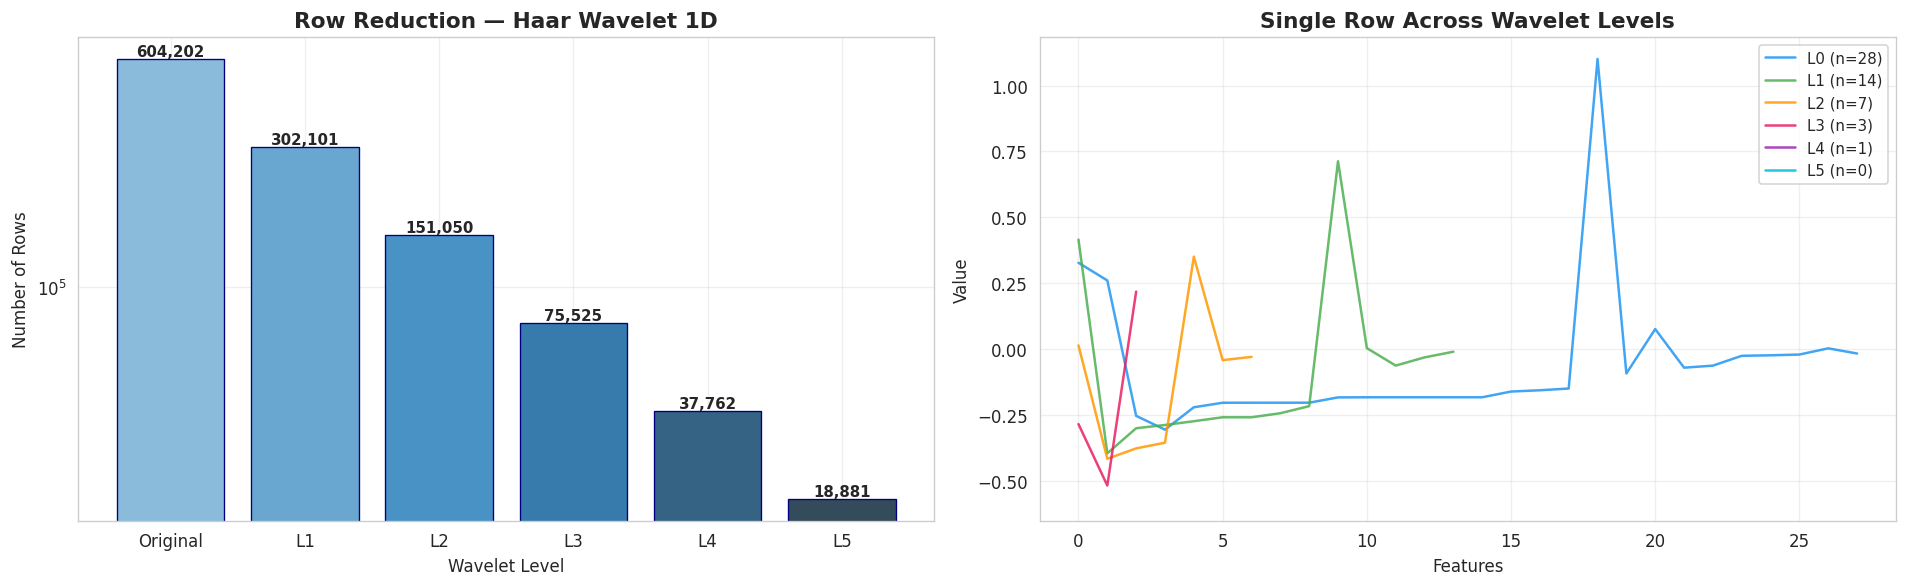

Wavelet plots saved


In [18]:
# Wavelet plots
_, level_shapes = haar_rows_5(X_train_sc, 'vis')
print('Train level summary:')
for i,sh in enumerate(level_shapes):
    print(f'  {"Original" if i==0 else f"L{i}":<8} {str(sh):<22} (divided by {"1" if i==0 else 2**i})')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rows_ls = [s[0] for s in level_shapes]
bars = axes[0].bar(range(len(rows_ls)), rows_ls,
                   color=sns.color_palette('Blues_d', len(rows_ls)), edgecolor='navy', lw=0.8)
for b,v in zip(bars,rows_ls):
    axes[0].text(b.get_x()+b.get_width()/2, v*1.02, f'{v:,}',
                 ha='center', fontweight='bold', fontsize=9)
axes[0].set_xticks(range(len(rows_ls)))
axes[0].set_xticklabels(['Original']+[f'L{i}' for i in range(1,6)])
axes[0].set_xlabel('Wavelet Level'); axes[0].set_ylabel('Number of Rows')
axes[0].set_title('Row Reduction — Haar Wavelet 1D', fontsize=13, fontweight='bold')
axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)

# Single row across levels
r0 = X_train_sc[0].copy()
rls = [r0]
for _ in range(5):
    r0 = (r0[0::2]+r0[1::2])/SQRT2 if len(r0)%2==0 else (r0[:-1][0::2]+r0[:-1][1::2])/SQRT2
    rls.append(r0.copy())

colors_w = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
for i,(rd,c) in enumerate(zip(rls,colors_w)):
    axes[1].plot(rd, color=c, lw=1.5, alpha=0.85, label=f'L{i} (n={len(rd)})')
axes[1].set_xlabel('Features'); axes[1].set_ylabel('Value')
axes[1].set_title('Single Row Across Wavelet Levels', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/08_wavelet.png', bbox_inches='tight'); plt.show()
print('Wavelet plots saved')

## Step 10: Train 6 Algorithms — After Wavelet

In [19]:
# 1. RF + Wavelet
print('='*55); print('1. RF (After Wavelet)'); print('='*55)
t0 = time.time()
rf_w = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=3,
                               class_weight='balanced', random_state=42, n_jobs=-1)
rf_w.fit(X_train_wav, y_train_wav)
yp = rf_w.predict(X_test_wav)
ypr = rf_w.predict_proba(X_test_wav)[:,1]
res_rf_w = evaluate_model('RF', y_test_wav, yp, ypr)
res_rf_w['time'] = time.time()-t0
print(f'Time: {res_rf_w["time"]:.1f}s'); print_results(res_rf_w)

1. RF (After Wavelet)
Time: 4.7s
  Accuracy:  91.725%
  Precision: 91.694%
  Recall:    100.000%
  F1-Score:  95.667%
  ROC-AUC:   81.886%
              precision    recall  f1-score   support

      Normal       1.00      0.04      0.08       484
      Attack       0.92      1.00      0.96      5111

    accuracy                           0.92      5595
   macro avg       0.96      0.52      0.52      5595
weighted avg       0.92      0.92      0.88      5595



In [20]:
# 2. DNN + Wavelet
print('='*55); print('2. DNN (After Wavelet)'); print('='*55)
t0 = time.time()
dnn_w = build_dnn(X_train_wav.shape[1])
cw_arr_w = compute_class_weight('balanced', classes=np.unique(y_train_wav), y=y_train_wav)
cw_w = {int(k): v for k, v in zip(np.unique(y_train_wav), cw_arr_w)}
print(f'Class weights: {cw_w}')

cb_w = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                   restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                                       patience=5, min_lr=1e-6, mode='max'),
    keras.callbacks.ModelCheckpoint('/content/dnn_w.keras', monitor='val_auc',
                                     mode='max', save_best_only=True, verbose=0)
]
hist_w = dnn_w.fit(X_train_wav, y_train_wav,
                    validation_data=(X_val_wav, y_val_wav),
                    epochs=80, batch_size=256,
                    class_weight=cw_w, callbacks=cb_w, verbose=1)

# Threshold tuning on Val
val_probs_w = dnn_w.predict(X_val_wav, batch_size=1024, verbose=0).flatten()
best_thresh_w = 0.5
best_f1_w = 0
for t in np.arange(0.1, 0.9, 0.05):
    yp_t = (val_probs_w >= t).astype(int)
    f1_t = f1_score(y_val_wav, yp_t, zero_division=0)
    if f1_t > best_f1_w:
        best_f1_w = f1_t
        best_thresh_w = t
print(f'\nBest threshold on Val: {best_thresh_w:.2f} (F1={best_f1_w:.4f})')

ypr = dnn_w.predict(X_test_wav, batch_size=1024, verbose=0).flatten()
yp  = (ypr >= best_thresh_w).astype(int)
res_dnn_w = evaluate_model('DNN', y_test_wav, yp, ypr)
res_dnn_w['time'] = time.time()-t0
res_dnn_w['history'] = hist_w.history
print(f'\nTime: {res_dnn_w["time"]:.1f}s'); print_results(res_dnn_w)

2. DNN (After Wavelet)
Class weights: {0: np.float64(14.412977099236642), 1: np.float64(0.5179688357291781)}
Epoch 1/80
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6907 - auc: 0.9500 - loss: 0.4078 - precision: 0.9986 - recall: 0.6806 - val_accuracy: 0.6346 - val_auc: 0.8631 - val_loss: 2.0663 - val_precision: 0.9897 - val_recall: 0.6048 - learning_rate: 0.0010
Epoch 2/80
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9118 - auc: 0.9898 - loss: 0.2060 - precision: 0.9998 - recall: 0.9088 - val_accuracy: 0.9135 - val_auc: 0.8399 - val_loss: 1.4655 - val_precision: 0.9601 - val_recall: 0.9442 - learning_rate: 0.0010
Epoch 3/80
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9502 - auc: 0.9949 - loss: 0.1363 - precision: 0.9998 - recall: 0.9485 - val_accuracy: 0.9224 - val_auc: 0.8354 - val_loss: 4.4670 - val_precision: 0.9538 - val_recall: 0.9613 - learning_rate: 0.0010
Epoch 4/80
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9708 - auc: 0.9978 - loss: 0.0957 

In [21]:
# 3. LGBM + Wavelet
print('='*55); print('3. LGBM (After Wavelet)'); print('='*55)
t0 = time.time()
print(f'Classes in Train_wav: {np.unique(y_train_wav)}')
neg_w,pos_w = (y_train_wav==0).sum(),(y_train_wav==1).sum()
print(f'scale_pos_weight = {neg_w/pos_w:.2f}')

lgbm_w = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=8,
                              num_leaves=63, min_child_samples=5,
                              scale_pos_weight=neg_w/pos_w,
                              subsample=0.8, colsample_bytree=0.8,
                              reg_alpha=0.1, reg_lambda=0.1,
                              random_state=42, n_jobs=-1, verbose=-1)
lgbm_w.fit(X_train_wav, y_train_wav,
            eval_set=[(X_val_wav, y_val_wav)],
            callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(100)])
yp = lgbm_w.predict(X_test_wav)
ypr = lgbm_w.predict_proba(X_test_wav)[:,1]
res_lgbm_w = evaluate_model('LGBM', y_test_wav, yp, ypr)
res_lgbm_w['time'] = time.time()-t0
print(f'Time: {res_lgbm_w["time"]:.1f}s'); print_results(res_lgbm_w)

3. LGBM (After Wavelet)
Classes in Train_wav: [0 1]
scale_pos_weight = 0.04
Time: 1.0s
  Accuracy:  94.906%
  Precision: 95.255%
  Recall:    99.374%
  F1-Score:  97.271%
  ROC-AUC:   77.568%
              precision    recall  f1-score   support

      Normal       0.88      0.48      0.62       484
      Attack       0.95      0.99      0.97      5111

    accuracy                           0.95      5595
   macro avg       0.92      0.74      0.80      5595
weighted avg       0.95      0.95      0.94      5595



In [22]:
# 4. DT + Wavelet
print('='*55); print('4. DT (After Wavelet)'); print('='*55)
t0 = time.time()
dt_w = DecisionTreeClassifier(max_depth=12, class_weight='balanced',
                               min_samples_leaf=5, min_samples_split=10,
                               random_state=42)
dt_w.fit(X_train_wav, y_train_wav)
yp = dt_w.predict(X_test_wav)
ypr = dt_w.predict_proba(X_test_wav)[:,1]
res_dt_w = evaluate_model('DT', y_test_wav, yp, ypr)
res_dt_w['time'] = time.time()-t0
print(f'Time: {res_dt_w["time"]:.1f}s'); print_results(res_dt_w)

4. DT (After Wavelet)
Time: 0.2s
  Accuracy:  93.101%
  Precision: 94.167%
  Recall:    98.552%
  F1-Score:  96.310%
  ROC-AUC:   67.045%
              precision    recall  f1-score   support

      Normal       0.70      0.36      0.47       484
      Attack       0.94      0.99      0.96      5111

    accuracy                           0.93      5595
   macro avg       0.82      0.67      0.72      5595
weighted avg       0.92      0.93      0.92      5595



In [23]:
# 5. LR + Wavelet
print('='*55); print('5. LR (After Wavelet)'); print('='*55)
t0 = time.time()
lr_w = LogisticRegression(max_iter=2000, class_weight='balanced',
                           C=0.1, solver='lbfgs', random_state=42, n_jobs=-1)
lr_w.fit(X_train_wav, y_train_wav)
yp = lr_w.predict(X_test_wav)
ypr = lr_w.predict_proba(X_test_wav)[:,1]
res_lr_w = evaluate_model('LR', y_test_wav, yp, ypr)
res_lr_w['time'] = time.time()-t0
print(f'Time: {res_lr_w["time"]:.1f}s'); print_results(res_lr_w)

5. LR (After Wavelet)
Time: 1.5s
  Accuracy:  93.905%
  Precision: 94.680%
  Recall:    98.885%
  F1-Score:  96.737%
  ROC-AUC:   86.102%
              precision    recall  f1-score   support

      Normal       0.78      0.41      0.54       484
      Attack       0.95      0.99      0.97      5111

    accuracy                           0.94      5595
   macro avg       0.86      0.70      0.75      5595
weighted avg       0.93      0.94      0.93      5595



In [24]:
# 6. SVM + Wavelet
print('='*55); print('6. SVM (After Wavelet)'); print('='*55)
t0 = time.time()
svm_bw = LinearSVC(max_iter=5000, class_weight='balanced', C=0.1, random_state=42)
svm_w = CalibratedClassifierCV(svm_bw, cv=3, method='sigmoid')
svm_w.fit(X_train_wav, y_train_wav)
yp = svm_w.predict(X_test_wav)
ypr = svm_w.predict_proba(X_test_wav)[:,1]
res_svm_w = evaluate_model('SVM', y_test_wav, yp, ypr)
res_svm_w['time'] = time.time()-t0
print(f'Time: {res_svm_w["time"]:.1f}s'); print_results(res_svm_w)

6. SVM (After Wavelet)
Time: 0.3s
  Accuracy:  91.886%
  Precision: 91.932%
  Recall:    99.883%
  F1-Score:  95.743%
  ROC-AUC:   88.608%
              precision    recall  f1-score   support

      Normal       0.86      0.07      0.14       484
      Attack       0.92      1.00      0.96      5111

    accuracy                           0.92      5595
   macro avg       0.89      0.54      0.55      5595
weighted avg       0.91      0.92      0.89      5595



In [25]:
results_wav = {'RF':res_rf_w,'DNN':res_dnn_w,'LGBM':res_lgbm_w,
               'DT':res_dt_w,'LR':res_lr_w,'SVM':res_svm_w}

print('\n' + '='*72)
print(f'{"Model":<8} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC":>10} {"Time":>8}')
print('='*72)
for nm,r in results_wav.items():
    print(f'{nm:<8} {r["accuracy"]*100:>9.2f}% {r["precision"]*100:>9.2f}% '
          f'{r["recall"]*100:>9.2f}% {r["f1"]*100:>9.2f}% '
          f'{r["auc"]*100:>9.2f}% {r["time"]:>7.1f}s')
print('='*72)


Model      Accuracy  Precision     Recall         F1        AUC     Time
RF           91.72%     91.69%    100.00%     95.67%     81.89%     4.7s
DNN          88.81%     95.39%     92.21%     93.77%     86.19%    12.6s
LGBM         94.91%     95.26%     99.37%     97.27%     77.57%     1.0s
DT           93.10%     94.17%     98.55%     96.31%     67.04%     0.2s
LR           93.91%     94.68%     98.88%     96.74%     86.10%     1.5s
SVM          91.89%     91.93%     99.88%     95.74%     88.61%     0.3s


## Step 11: Full Comparison

In [26]:
# Comparison table
print('\n' + '='*90)
print(f'{"Model":<8}  {"Acc(O)":>8} {"Acc(W)":>8}  {"F1(O)":>8} {"F1(W)":>8}  {"AUC(O)":>8} {"AUC(W)":>8}  {"dF1":>8}')
print('='*90)
for nm in MODEL_NAMES:
    ro,rw = results_orig[nm],results_wav[nm]
    df1 = (rw['f1']-ro['f1'])*100
    arr = '^' if df1>=0 else 'v'
    print(f'{nm:<8}  {ro["accuracy"]*100:>7.2f}% {rw["accuracy"]*100:>7.2f}%  '
          f'{ro["f1"]*100:>7.2f}% {rw["f1"]*100:>7.2f}%  '
          f'{ro["auc"]*100:>7.2f}% {rw["auc"]*100:>7.2f}%  '
          f'{arr}{abs(df1):>6.2f}%')
print('='*90)
print('  O=Without Wavelet  W=With Wavelet')

best_o = max(results_orig, key=lambda n: results_orig[n]['f1'])
best_w = max(results_wav,  key=lambda n: results_wav[n]['f1'])
print(f'\nBest (Without Wavelet): {best_o}  F1={results_orig[best_o]["f1"]*100:.2f}%  AUC={results_orig[best_o]["auc"]*100:.2f}%')
print(f'Best (With Wavelet):    {best_w}  F1={results_wav[best_w]["f1"]*100:.2f}%   AUC={results_wav[best_w]["auc"]*100:.2f}%')


Model       Acc(O)   Acc(W)     F1(O)    F1(W)    AUC(O)   AUC(W)       dF1
RF          90.06%   91.72%    59.47%   95.67%    99.11%   81.89%  ^ 36.20%
DNN         97.61%   88.81%    85.89%   93.77%    98.57%   86.19%  ^  7.88%
LGBM        89.99%   94.91%    59.29%   97.27%    94.69%   77.57%  ^ 37.98%
DT          97.73%   93.10%    86.52%   96.31%    98.78%   67.04%  ^  9.79%
LR          97.65%   93.91%    86.12%   96.74%    98.67%   86.10%  ^ 10.61%
SVM         93.99%   91.89%    70.79%   95.74%    98.29%   88.61%  ^ 24.95%
  O=Without Wavelet  W=With Wavelet

Best (Without Wavelet): DT  F1=86.52%  AUC=98.78%
Best (With Wavelet):    LGBM  F1=97.27%   AUC=77.57%


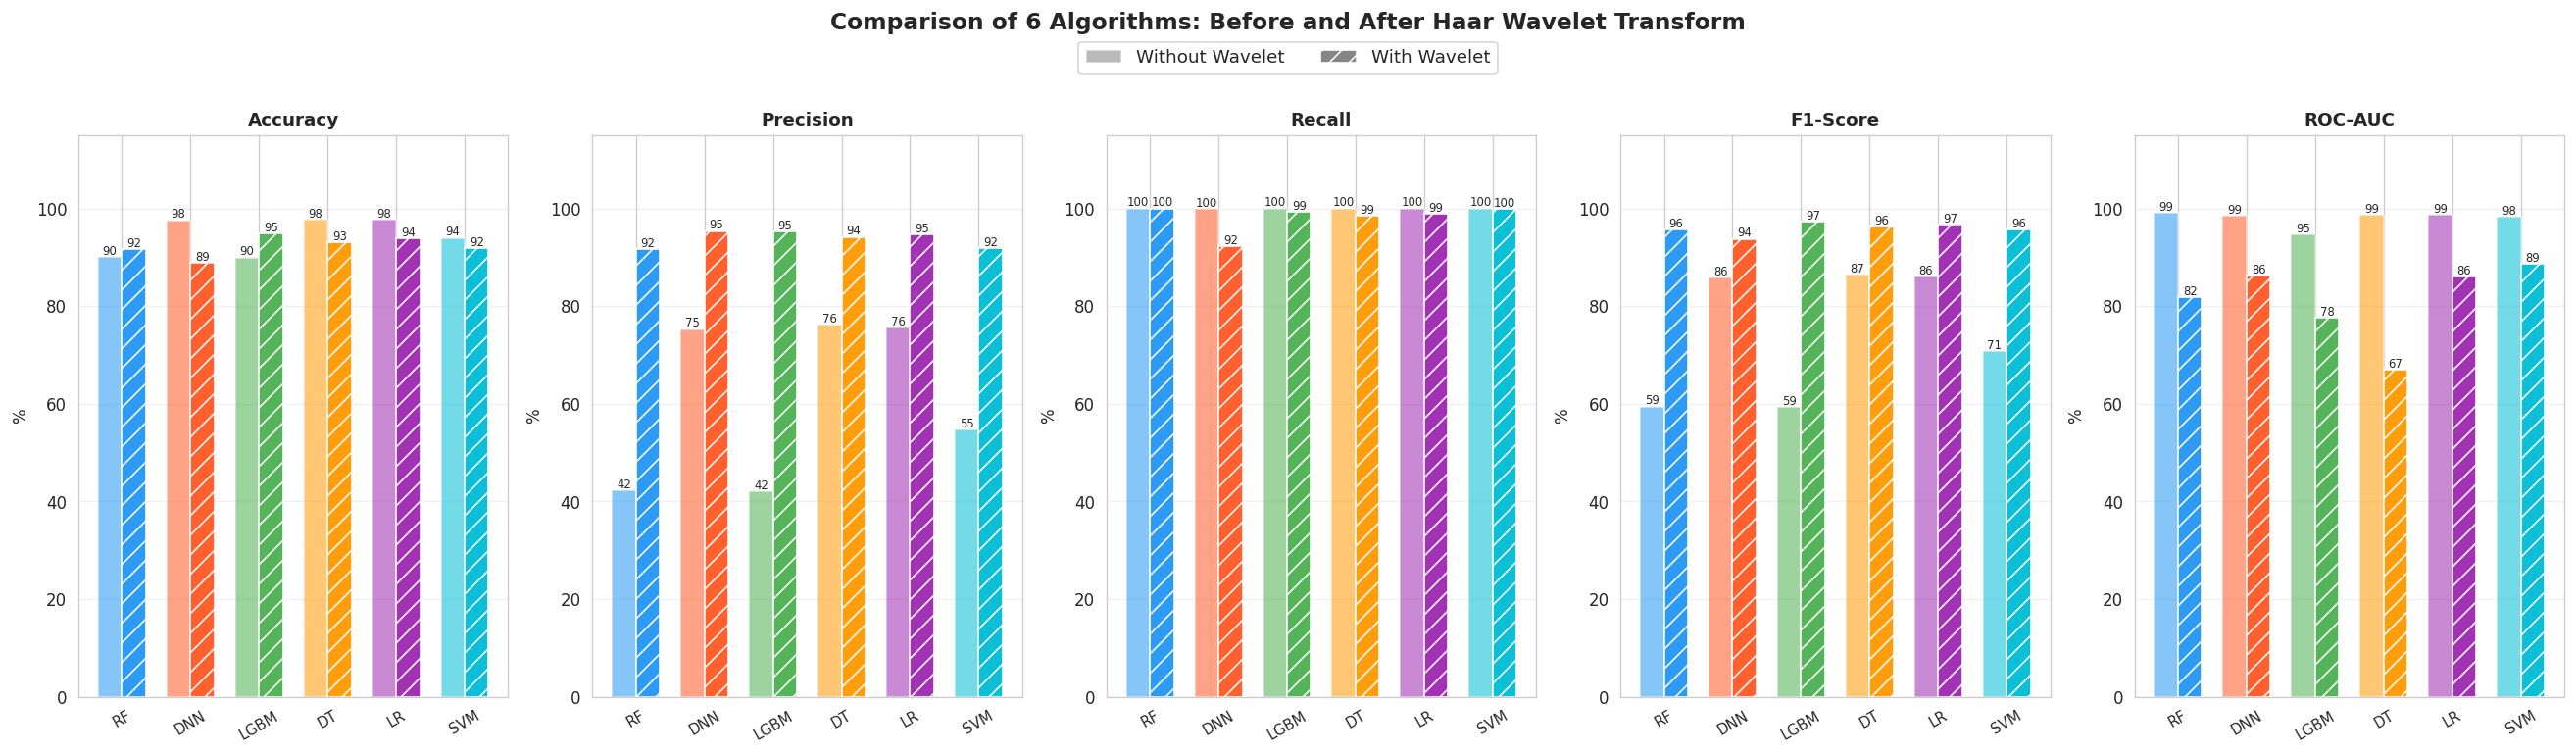

In [27]:
# Plot 1: Metrics comparison
metrics_plot = ['accuracy','precision','recall','f1','auc']
mlabels = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
for ax, metric, mlbl in zip(axes, metrics_plot, mlabels):
    x = np.arange(len(MODEL_NAMES)); w = 0.35
    vals_o = [results_orig[n][metric]*100 for n in MODEL_NAMES]
    vals_w = [results_wav[n][metric]*100  for n in MODEL_NAMES]
    bars_o = ax.bar(x-w/2, vals_o, w, label='Without Wavelet',
                    color=[MODEL_COLORS[n] for n in MODEL_NAMES], alpha=0.55, edgecolor='white')
    bars_w = ax.bar(x+w/2, vals_w, w, label='With Wavelet',
                    color=[MODEL_COLORS[n] for n in MODEL_NAMES], alpha=0.95, edgecolor='white', hatch='//')
    ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES, fontsize=9, rotation=30)
    ax.set_title(mlbl, fontweight='bold', fontsize=11)
    ax.set_ylabel('%'); ax.set_ylim(0, 115); ax.grid(True, axis='y', alpha=0.3)
    for b,v in zip(bars_o,vals_o): ax.text(b.get_x()+b.get_width()/2,v+0.5,f'{v:.0f}',ha='center',fontsize=7)
    for b,v in zip(bars_w,vals_w): ax.text(b.get_x()+b.get_width()/2,v+0.5,f'{v:.0f}',ha='center',fontsize=7)

hdl = [plt.Rectangle((0,0),1,1,fc='gray',alpha=0.55,label='Without Wavelet'),
       plt.Rectangle((0,0),1,1,fc='gray',alpha=0.95,hatch='//',label='With Wavelet')]
fig.legend(handles=hdl, loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5,1.03))
plt.suptitle('Comparison of 6 Algorithms: Before and After Haar Wavelet Transform',
             fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig('/content/11_comparison.png', bbox_inches='tight', dpi=130); plt.show()

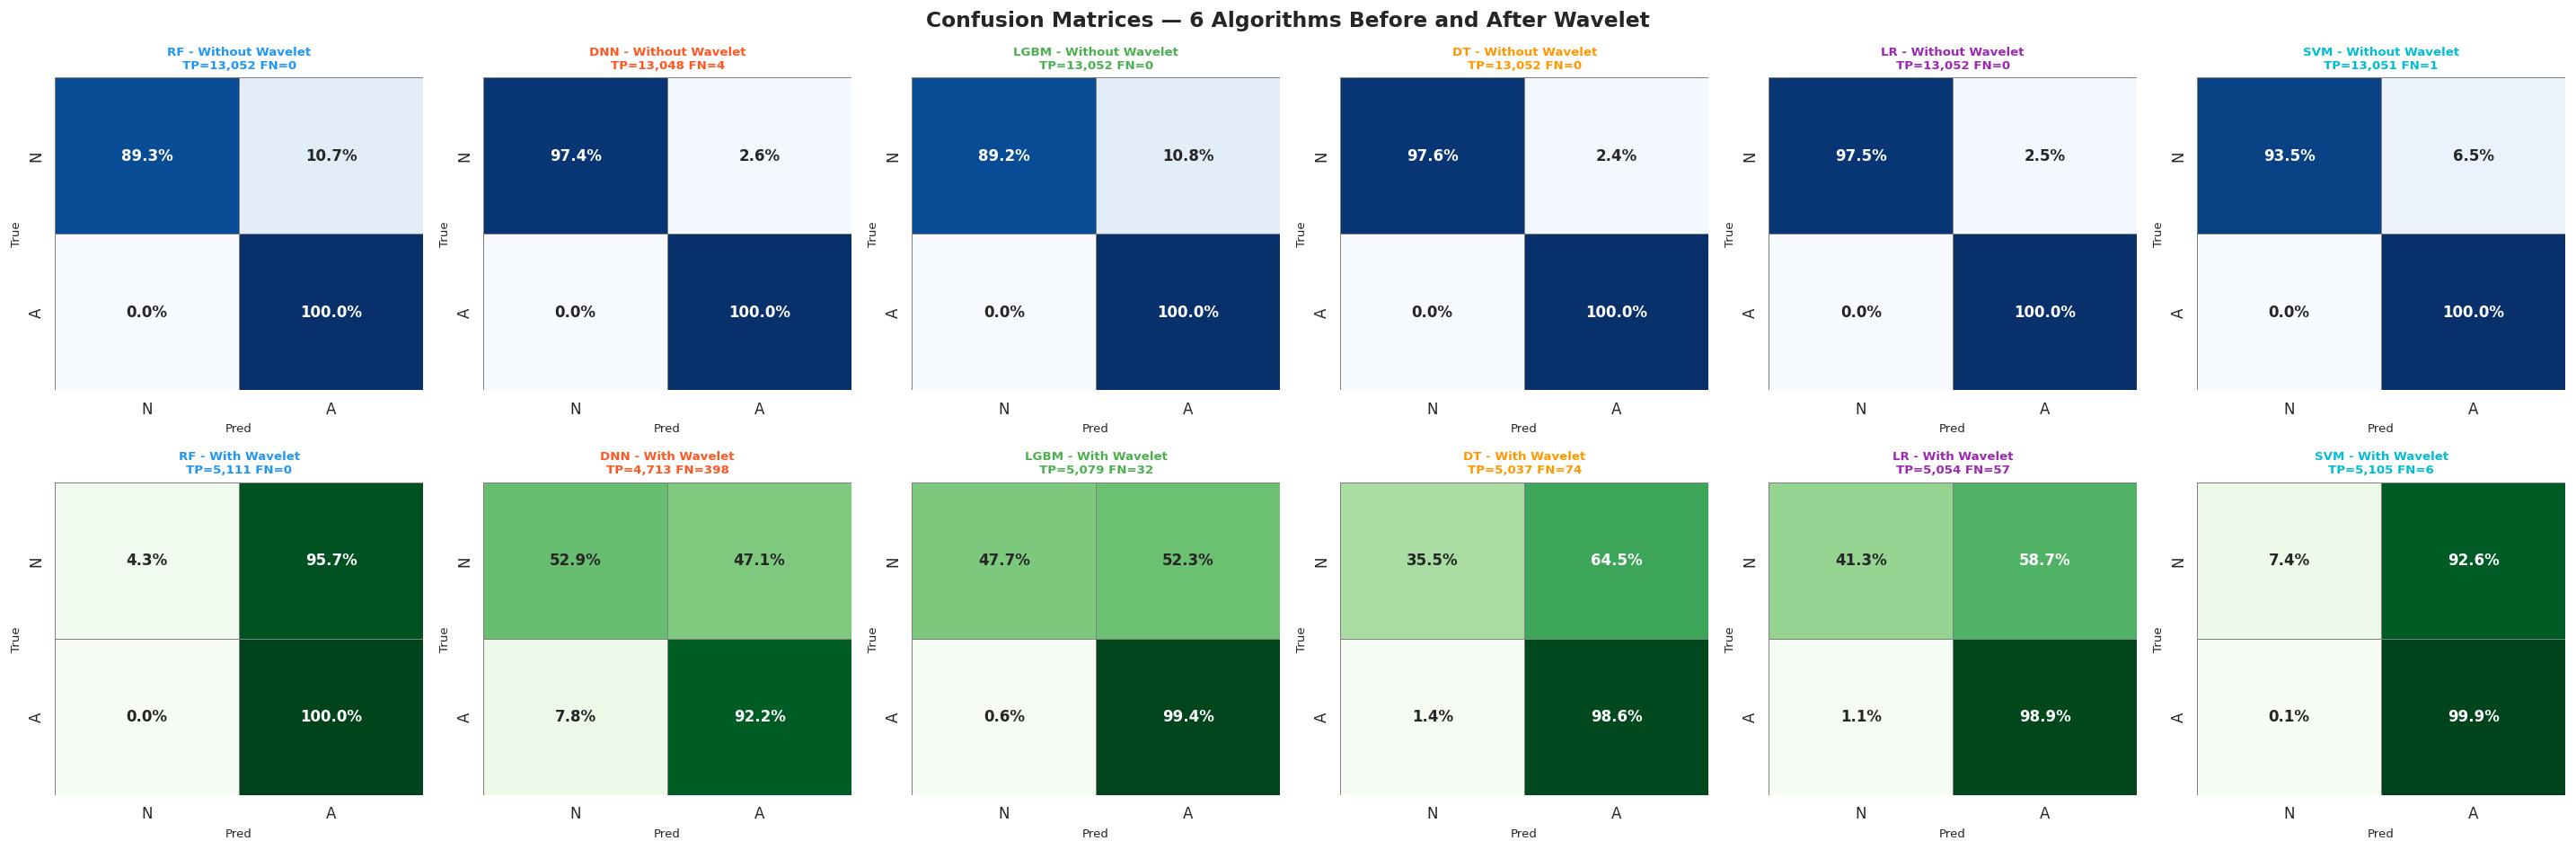

In [28]:
# Plot 2: Confusion Matrices (12 matrices)
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for col, nm in enumerate(MODEL_NAMES):
    for row, (res, lbl) in enumerate([(results_orig[nm],'Without Wavelet'),
                                       (results_wav[nm], 'With Wavelet')]):
        ax = axes[row,col]
        cm_pct = res['cm'].astype(float)/res['cm'].sum(axis=1,keepdims=True)*100
        ann = np.array([[f'{v:.1f}%' for v in r] for r in cm_pct])
        sns.heatmap(cm_pct, annot=ann, fmt='', cmap='Blues' if row==0 else 'Greens',
                    ax=ax, xticklabels=['N','A'], yticklabels=['N','A'],
                    linewidths=0.5, linecolor='gray',
                    annot_kws={'size':10,'weight':'bold'}, vmin=0, vmax=100, cbar=False)
        tn,fp,fn,tp = res['cm'].ravel()
        ax.set_title(f'{nm} - {lbl}\nTP={tp:,} FN={fn:,}', fontsize=8, fontweight='bold',
                     color=MODEL_COLORS[nm])
        ax.set_xlabel('Pred', fontsize=8); ax.set_ylabel('True', fontsize=8)

plt.suptitle('Confusion Matrices — 6 Algorithms Before and After Wavelet',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/12_confusion_matrices.png', bbox_inches='tight', dpi=130); plt.show()

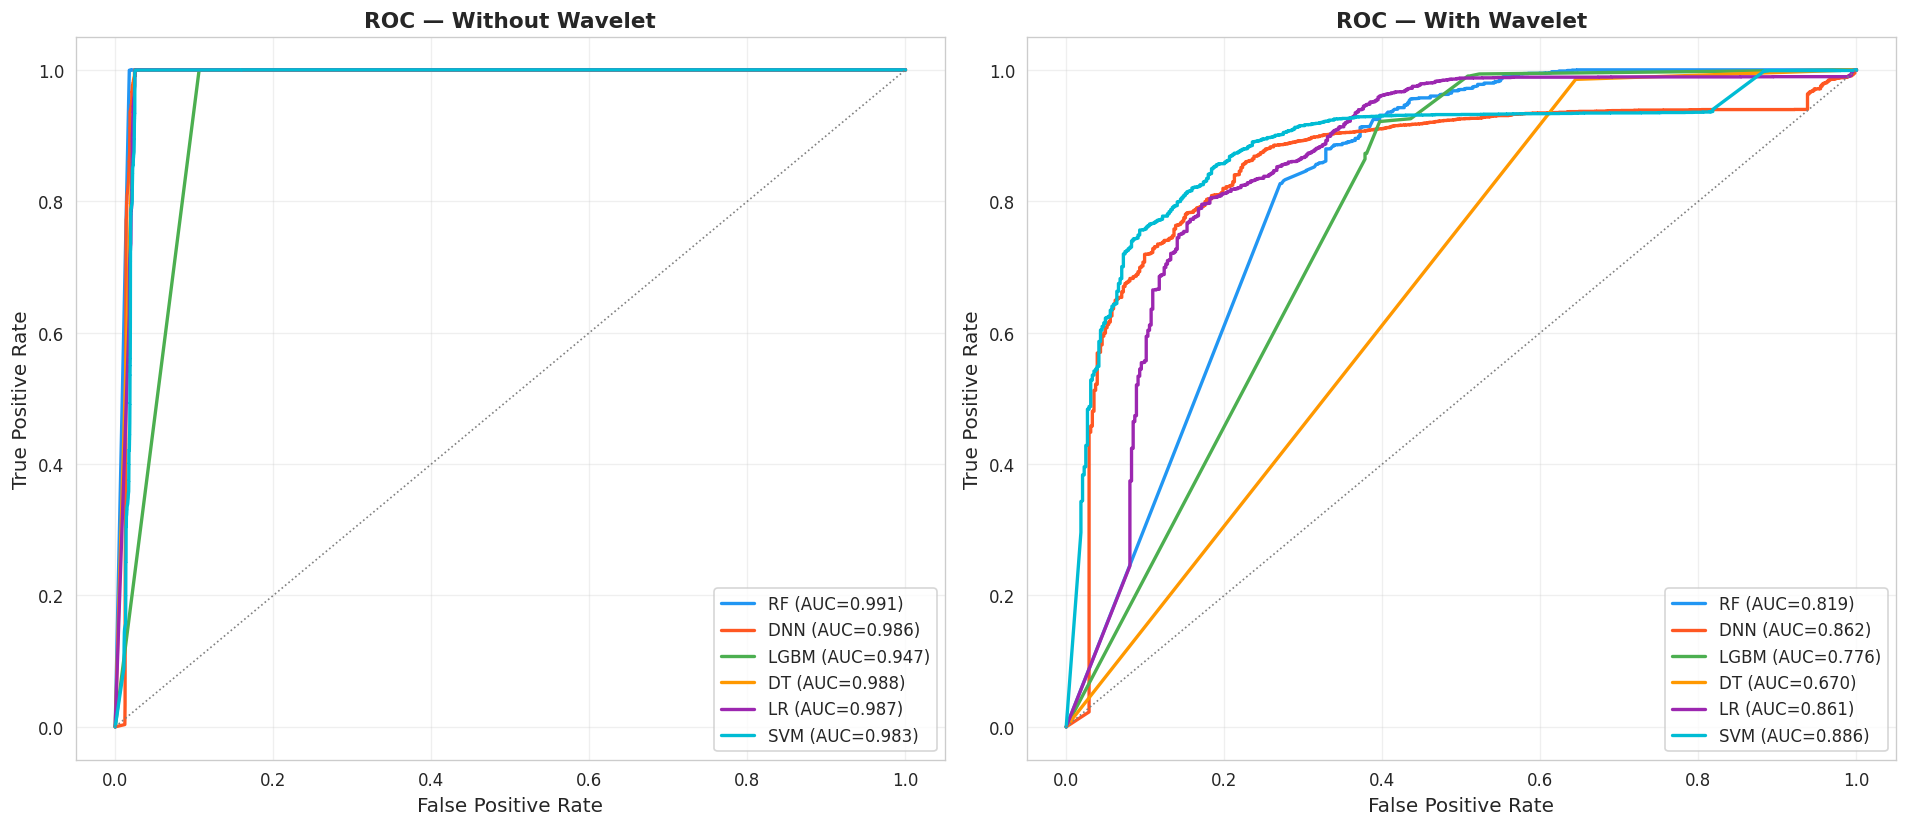

In [29]:
# Plot 3: ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_i, (res_dict, title_suf) in enumerate([
    (results_orig, 'Without Wavelet'),
    (results_wav,  'With Wavelet')
]):
    ax = axes[ax_i]
    for nm in MODEL_NAMES:
        res = res_dict[nm]
        fpr,tpr,_ = roc_curve(res['y_true'], res['y_prob'])
        ax.plot(fpr, tpr, color=MODEL_COLORS[nm], lw=2,
                label=f'{nm} (AUC={res["auc"]:.3f})')
    ax.plot([0,1],[0,1],'gray',lw=1,ls=':')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC — {title_suf}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/13_roc.png', bbox_inches='tight'); plt.show()

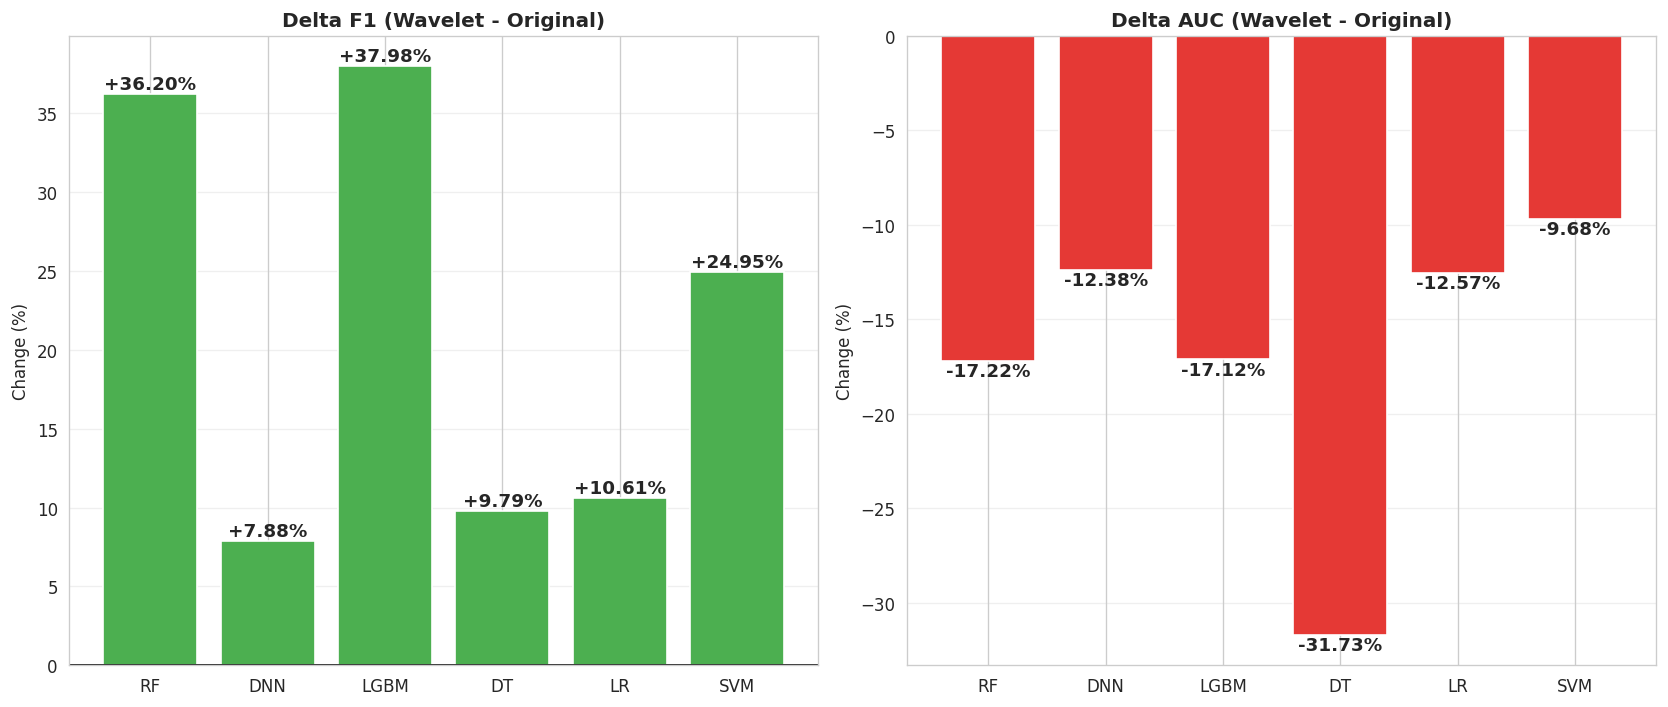

In [30]:
# Plot 4: Delta Performance
df1s  = [(results_wav[n]['f1'] -results_orig[n]['f1'])*100  for n in MODEL_NAMES]
daucs = [(results_wav[n]['auc']-results_orig[n]['auc'])*100 for n in MODEL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, deltas, title in [(axes[0],df1s,'Delta F1 (Wavelet - Original)'),
                           (axes[1],daucs,'Delta AUC (Wavelet - Original)')]:
    clrd = ['#4CAF50' if d>=0 else '#E53935' for d in deltas]
    bars = ax.bar(MODEL_NAMES, deltas, color=clrd, edgecolor='white')
    ax.axhline(0, color='black', lw=1)
    for b,v in zip(bars,deltas):
        ax.text(b.get_x()+b.get_width()/2, v+(0.3 if v>=0 else -0.8),
                f'{v:+.2f}%', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylabel('Change (%)')
plt.tight_layout()
plt.savefig('/content/14_delta.png', bbox_inches='tight'); plt.show()

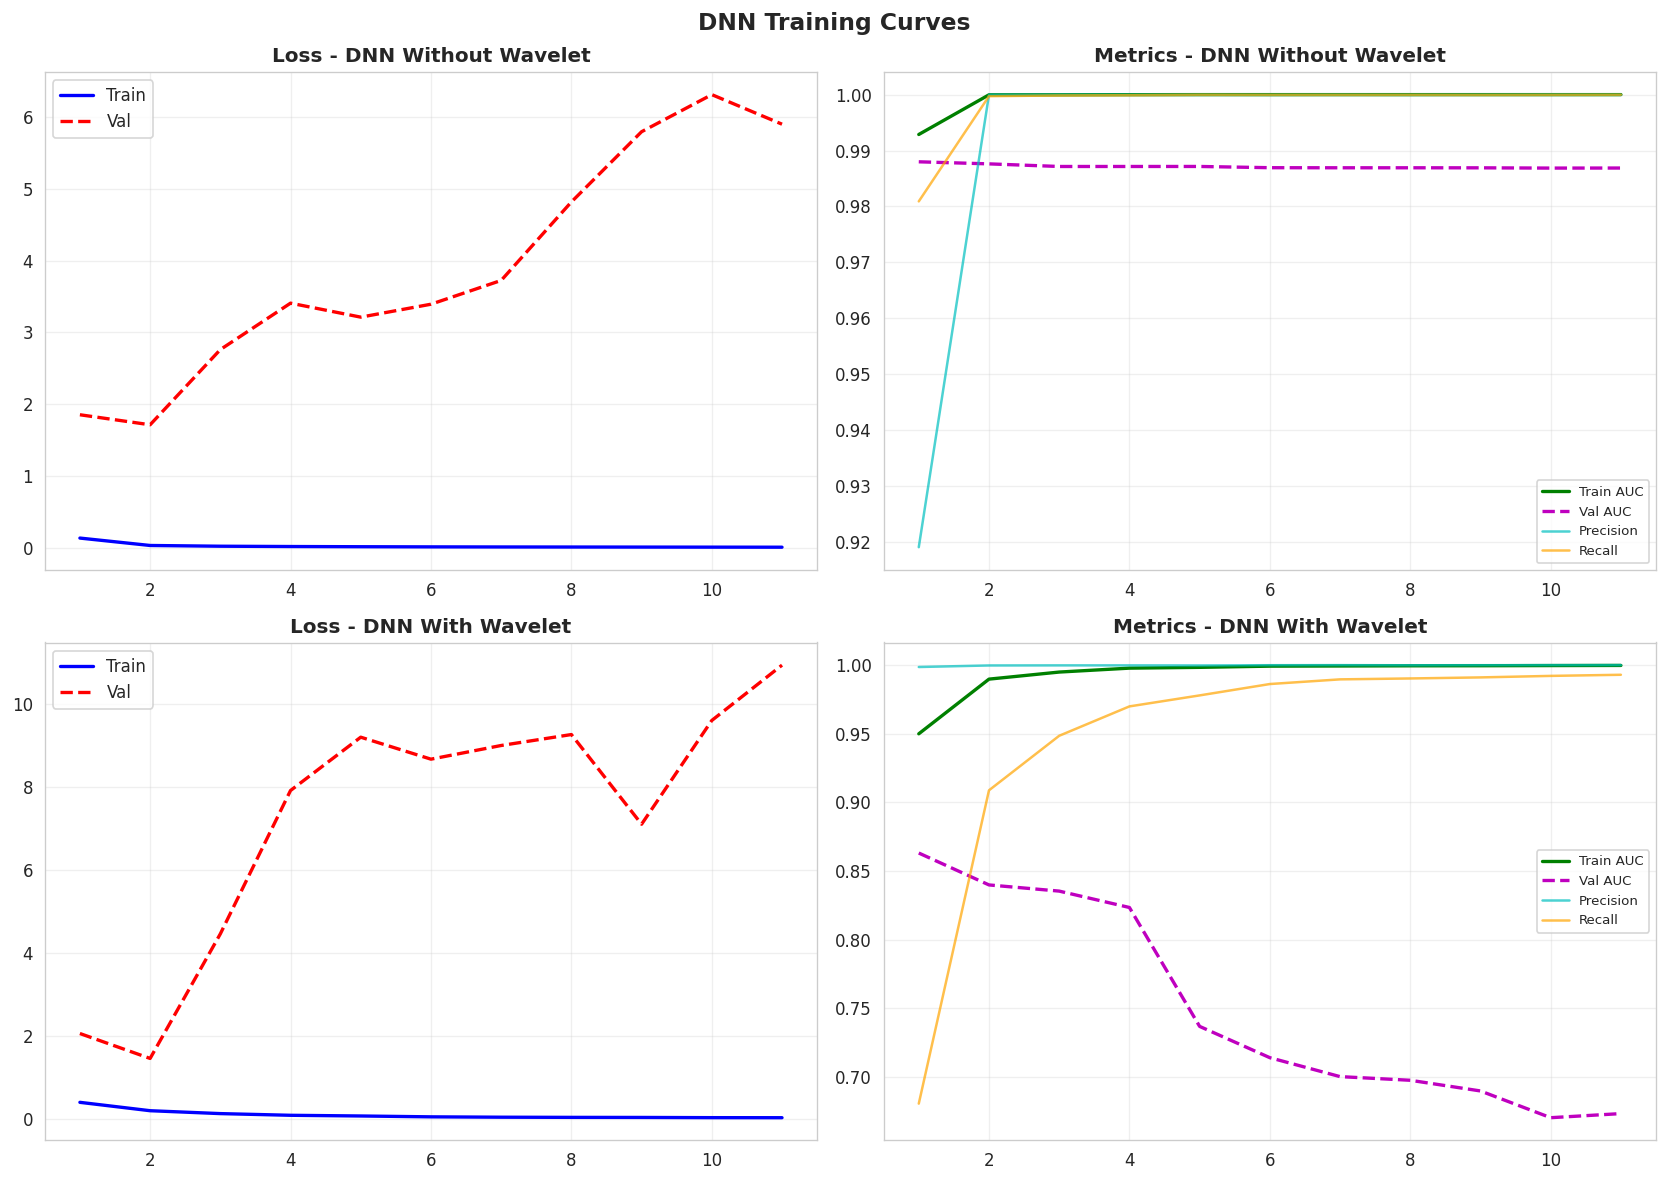

In [31]:
# Plot 5: DNN Training Curves
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for row,(h,lbl) in enumerate([(res_dnn_o['history'],'DNN Without Wavelet'),
                                (res_dnn_w['history'],'DNN With Wavelet')]):
    ep = range(1,len(h['loss'])+1)
    axes[row,0].plot(ep,h['loss'],'b-',lw=2,label='Train')
    axes[row,0].plot(ep,h['val_loss'],'r--',lw=2,label='Val')
    axes[row,0].set_title(f'Loss - {lbl}',fontweight='bold')
    axes[row,0].legend(); axes[row,0].grid(alpha=0.3)

    axes[row,1].plot(ep,h['auc'],'g-',lw=2,label='Train AUC')
    axes[row,1].plot(ep,h['val_auc'],'m--',lw=2,label='Val AUC')
    axes[row,1].plot(ep,h['precision'],'c-',lw=1.5,label='Precision',alpha=0.7)
    axes[row,1].plot(ep,h['recall'],color='orange',lw=1.5,label='Recall',alpha=0.7)
    axes[row,1].set_title(f'Metrics - {lbl}',fontweight='bold')
    axes[row,1].legend(fontsize=8); axes[row,1].grid(alpha=0.3)

plt.suptitle('DNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/15_dnn_curves.png', bbox_inches='tight'); plt.show()

## Step 12: Final Summary

In [32]:
print('\nFinal Summary')
print('='*80)
print(f'Original data: {n_rows_orig:,} rows x {n_cols_orig} columns')
print(f'After Preprocessing: {len(X_all):,} rows x {X_all.shape[1]} features')
print(f'After Feature Selection: {len(selected_feats)} features -> {selected_feats}')
print(f'Train (after Outlier Removal): {len(X_train_sc):,} rows')
print(f'   Normal: {(y_train==0).sum():,} | Attack: {(y_train==1).sum():,}')
print(f'Test: {len(X_test_sc):,} rows')
print()
print(f'After Wavelet L5:')
print(f'   Train: {X_train_wav.shape[0]:,} rows')
print(f'   Test:  {X_test_wav.shape[0]:,} rows')
print(f'   Columns: {X_test_wav.shape[1]} (unchanged)')
print()
print('-'*80)
print(f'{"Model":<8}  {"--- Without Wavelet ---":^36}  {"--- With Wavelet ---":^36}  {"dF1":>6}')
print(f'{"":8}  {"F1":>9} {"AUC":>9} {"Rec":>9} {"Pre":>9}  {"F1":>9} {"AUC":>9} {"Rec":>9} {"Pre":>9}  {"":6}')
print('-'*80)
for nm in MODEL_NAMES:
    ro,rw = results_orig[nm],results_wav[nm]
    df1=(rw['f1']-ro['f1'])*100
    print(f'{nm:<8}  {ro["f1"]*100:>8.2f}% {ro["auc"]*100:>8.2f}% {ro["recall"]*100:>8.2f}% {ro["precision"]*100:>8.2f}%  '
          f'{rw["f1"]*100:>8.2f}% {rw["auc"]*100:>8.2f}% {rw["recall"]*100:>8.2f}% {rw["precision"]*100:>8.2f}%  '
          f'{"+" if df1>=0 else "-"}{abs(df1):>5.2f}%')
print('-'*80)

bo=max(results_orig,key=lambda n:results_orig[n]['f1'])
bw=max(results_wav, key=lambda n:results_wav[n]['f1'])
print(f'\nBest Without Wavelet: {bo}  F1={results_orig[bo]["f1"]*100:.2f}%  AUC={results_orig[bo]["auc"]*100:.2f}%')
print(f'Best With Wavelet:    {bw}  F1={results_wav[bw]["f1"]*100:.2f}%   AUC={results_wav[bw]["auc"]*100:.2f}%')


Final Summary
Original data: 1,194,464 rows x 49 columns
After Preprocessing: 1,193,761 rows x 41 features
After Feature Selection: 28 features -> ['dTtl', 'Sport', 'SynAck', 'TcpRtt', 'pLoss', 'Load', 'Rate', 'SrcRate', 'SrcLoad', 'Mean', 'Min', 'Sum', 'RunTime', 'Dur', 'Max', 'SrcJitAct', 'sTtl', 'SIntPkt', 'IdleTime', 'Dport', 'DIntPkt', 'SAppBytes', 'SrcJitter', 'SrcBytes', 'SrcPkts', 'Proto', 'DstJitter', 'TotPkts']
Train (after Outlier Removal): 604,202 rows
   Normal: 543,294 | Attack: 60,908
Test: 179,065 rows

After Wavelet L5:
   Train: 18,881 rows
   Test:  5,595 rows
   Columns: 28 (unchanged)

--------------------------------------------------------------------------------
Model           --- Without Wavelet ---                 --- With Wavelet ---             dF1
                 F1       AUC       Rec       Pre         F1       AUC       Rec       Pre        
--------------------------------------------------------------------------------
RF           59.47%    99.11%  

## Download Results

In [33]:
import zipfile
from google.colab import files
zp = '/content/IIoT_Results_Fixed.zip'
with zipfile.ZipFile(zp,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(glob.glob('/content/*.png')): zf.write(f,os.path.basename(f))
    for f in ['/content/dnn_o.keras','/content/dnn_w.keras']:
        if os.path.exists(f): zf.write(f,os.path.basename(f))
print(f'ZIP size: {os.path.getsize(zp)/1e6:.1f} MB')
for f in sorted(glob.glob('/content/*.png')): print(f'  {os.path.basename(f)}  ({os.path.getsize(f)/1024:.0f}KB)')
files.download(zp)
print('Download complete!')

ZIP size: 1.2 MB
  01_eda.png  (69KB)
  05_pearson_corr.png  (87KB)
  07_normalization.png  (120KB)
  08_wavelet.png  (87KB)
  11_comparison.png  (163KB)
  12_confusion_matrices.png  (138KB)
  13_roc.png  (144KB)
  14_delta.png  (57KB)
  15_dnn_curves.png  (130KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!


In [34]:
import joblib

# حفظ أدوات المعالجة
joblib.dump(scaler,        '/content/scaler.pkl')
joblib.dump(selected_idx,  '/content/selected_idx.pkl')
joblib.dump(selected_feats,'/content/selected_feats.pkl')
joblib.dump(feature_names, '/content/feature_names.pkl')
joblib.dump(iqr_bounds,    '/content/iqr_bounds.pkl')

# حفظ النماذج
joblib.dump(rf_o,   '/content/rf_model.pkl')
joblib.dump(lgbm_o, '/content/lgbm_model.pkl')
joblib.dump(dt_o,   '/content/dt_model.pkl')
joblib.dump(lr_o,   '/content/lr_model.pkl')
joblib.dump(svm_o,  '/content/svm_model.pkl')

print("تم حفظ جميع الملفات بنجاح")

تم حفظ جميع الملفات بنجاح


In [35]:
import shutil

files_to_save = [
    'scaler.pkl', 'selected_idx.pkl', 'selected_feats.pkl',
    'feature_names.pkl', 'iqr_bounds.pkl', 'rf_model.pkl',
    'lgbm_model.pkl', 'dt_model.pkl', 'lr_model.pkl', 'svm_model.pkl'
]

save_dir = '/content/drive/MyDrive/IIoT_Models/'
import os; os.makedirs(save_dir, exist_ok=True)

for f in files_to_save:
    src = f'/content/{f}'
    if os.path.exists(src):
        shutil.copy(src, save_dir + f)
        print(f"محفوظ: {f}")
    else:
        print(f"غير موجود: {f}")

محفوظ: scaler.pkl
محفوظ: selected_idx.pkl
محفوظ: selected_feats.pkl
محفوظ: feature_names.pkl
محفوظ: iqr_bounds.pkl
محفوظ: rf_model.pkl
محفوظ: lgbm_model.pkl
محفوظ: dt_model.pkl
محفوظ: lr_model.pkl
محفوظ: svm_model.pkl


In [36]:
# بدلاً من /content/feature_names.pkl
MODELS_DIR = '/content/drive/MyDrive/IIoT_Models/'

feature_names  = joblib.load(MODELS_DIR + 'feature_names.pkl')
selected_idx   = joblib.load(MODELS_DIR + 'selected_idx.pkl')
scaler         = joblib.load(MODELS_DIR + 'scaler.pkl')
rf_model       = joblib.load(MODELS_DIR + 'rf_model.pkl')

In [37]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score

MODELS_DIR = '/content/drive/MyDrive/IIoT_Models/'

# ── الخطوة 1: تحميل الداتا الخارجية ──
df_ext = pd.read_csv('/content/drive/MyDrive/wustl-scada-2018.csv', low_memory=False)
print(f"شكل الداتا الخارجية: {df_ext.shape}")
print(f"الأعمدة: {df_ext.columns.tolist()}")

# ── الخطوة 2: استخراج Target ──
has_labels = 'Target' in df_ext.columns
if has_labels:
    y_ext = df_ext['Target'].astype(int).values
    df_ext_features = df_ext.drop(columns=['Target'])
else:
    df_ext_features = df_ext.copy()

# ── الخطوة 3: حذف أعمدة المعرّفات ──
drop_cols = ['StartTime','LastTime','SrcAddr','DstAddr','sIpId','dIpId','Traffic']
df_ext_features.drop(
    columns=[c for c in drop_cols if c in df_ext_features.columns],
    inplace=True
)

# تشفير النصي
cat_cols = df_ext_features.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_ext_features[col] = le.fit_transform(df_ext_features[col].astype(str))

print(f"\nالأعمدة بعد المعالجة: {df_ext_features.columns.tolist()}")

# ── الخطوة 4: اكتشاف الأعمدة المشتركة ──
feature_names  = joblib.load(MODELS_DIR + 'feature_names.pkl')
selected_feats = joblib.load(MODELS_DIR + 'selected_feats.pkl')
ext_cols       = df_ext_features.columns.tolist()

common_features  = [f for f in selected_feats if f in ext_cols]
missing_features = [f for f in selected_feats if f not in ext_cols]

print(f"\nأعمدة الموديل المختارة : {len(selected_feats)}")
print(f"أعمدة مشتركة          : {len(common_features)} -> {common_features}")
print(f"أعمدة مفقودة          : {len(missing_features)} -> {missing_features}")

شكل الداتا الخارجية: (7037983, 7)
الأعمدة: ['Sport', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'Target']

الأعمدة بعد المعالجة: ['Sport', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes']

أعمدة الموديل المختارة : 28
أعمدة مشتركة          : 4 -> ['Sport', 'SrcBytes', 'SrcPkts', 'TotPkts']
أعمدة مفقودة          : 24 -> ['dTtl', 'SynAck', 'TcpRtt', 'pLoss', 'Load', 'Rate', 'SrcRate', 'SrcLoad', 'Mean', 'Min', 'Sum', 'RunTime', 'Dur', 'Max', 'SrcJitAct', 'sTtl', 'SIntPkt', 'IdleTime', 'Dport', 'DIntPkt', 'SAppBytes', 'SrcJitter', 'Proto', 'DstJitter']


In [38]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix

MODELS_DIR = '/content/drive/MyDrive/IIoT_Models/'

# تحميل الداتا الأصلية
df_original = pd.read_csv('/content/drive/MyDrive/wustl_iiot_2021.csv', low_memory=False)

# أخذ 10 Normal + 10 Attack عشوائياً
normal_samples = df_original[df_original['Target'] == 0].sample(n=10, random_state=99)
attack_samples = df_original[df_original['Target'] == 1].sample(n=10, random_state=99)
df_sample = pd.concat([normal_samples, attack_samples]).sample(frac=1, random_state=99).reset_index(drop=True)

print("العينات المختارة:")
print(f"  Normal : {(df_sample['Target']==0).sum()}")
print(f"  Attack : {(df_sample['Target']==1).sum()}")
print(f"  المجموع: {len(df_sample)}")
print()

# استخراج Target
y_true  = df_sample['Target'].astype(int).values
df_feat = df_sample.drop(columns=['Target'])

# حذف أعمدة المعرّفات
drop_cols = ['StartTime','LastTime','SrcAddr','DstAddr','sIpId','dIpId','Traffic']
df_feat.drop(columns=[c for c in drop_cols if c in df_feat.columns], inplace=True)

# تشفير النصي
cat_cols = df_feat.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_feat[col] = le.fit_transform(df_feat[col].astype(str))

# تحميل أدوات التدريب — الإصلاح هنا
feature_names = joblib.load(MODELS_DIR + 'feature_names.pkl')
selected_idx  = joblib.load(MODELS_DIR + 'selected_idx.pkl')
scaler        = joblib.load(MODELS_DIR + 'scaler.pkl')       # scaler.pkl وليس rf_model.pkl
rf_model      = joblib.load(MODELS_DIR + 'rf_model.pkl')

# Feature Selection + Normalization
df_feat = df_feat[feature_names]
X       = df_feat.values[:, selected_idx]
X_sc    = scaler.transform(X).astype(np.float32)

# التنبؤ
predictions   = rf_model.predict(X_sc)
probabilities = rf_model.predict_proba(X_sc)[:, 1]

# عرض نتيجة كل عينة
print("="*62)
print(f"{'#':<4} {'الحقيقي':<12} {'التنبؤ':<12} {'احتمال Attack':<16} {'النتيجة'}")
print("="*62)
for i in range(len(df_sample)):
    actual    = "Normal" if y_true[i] == 0 else "Attack"
    predicted = "Normal" if predictions[i] == 0 else "Attack"
    prob      = probabilities[i]
    status    = "CORRECT" if y_true[i] == predictions[i] else "WRONG"
    print(f"{i+1:<4} {actual:<12} {predicted:<12} {prob:<16.4f} {status}")

# النتائج الإجمالية
correct = (y_true == predictions).sum()
print("="*62)
print(f"\nالنتائج الإجمالية:")
print(f"  صحيح    : {correct}/20")
print(f"  خطأ     : {20-correct}/20")
print(f"  Accuracy : {accuracy_score(y_true, predictions)*100:.1f}%")
print(f"  F1-Score : {f1_score(y_true, predictions)*100:.1f}%")
print(f"  ROC-AUC  : {roc_auc_score(y_true, probabilities)*100:.1f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, predictions)
print(f"\nConfusion Matrix:")
print(f"               Pred Normal   Pred Attack")
print(f"  True Normal       {cm[0,0]}             {cm[0,1]}")
print(f"  True Attack       {cm[1,0]}             {cm[1,1]}")

العينات المختارة:
  Normal : 10
  Attack : 10
  المجموع: 20

#    الحقيقي      التنبؤ       احتمال Attack    النتيجة
1    Attack       Attack       1.0000           CORRECT
2    Attack       Attack       1.0000           CORRECT
3    Attack       Attack       1.0000           CORRECT
4    Attack       Attack       1.0000           CORRECT
5    Normal       Normal       0.0000           CORRECT
6    Normal       Normal       0.0000           CORRECT
7    Attack       Attack       1.0000           CORRECT
8    Attack       Attack       1.0000           CORRECT
9    Attack       Attack       1.0000           CORRECT
10   Normal       Normal       0.4547           CORRECT
11   Attack       Attack       1.0000           CORRECT
12   Attack       Attack       1.0000           CORRECT
13   Normal       Normal       0.0000           CORRECT
14   Normal       Normal       0.0000           CORRECT
15   Normal       Normal       0.0000           CORRECT
16   Attack       Attack       1.0000      

In [42]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix
import random

MODELS_DIR = '/content/drive/MyDrive/IIoT_Models/'

# تحميل الداتا الأصلية
df_original = pd.read_csv('/content/drive/MyDrive/wustl_iiot_2021.csv', low_memory=False)

# seed عشوائي مختلف في كل تشغيل
seed = random.randint(0, 99999)
print(f"  Seed هذا التشغيل: {seed}")

# أخذ 10 Normal + 10 Attack عشوائياً — مختلفة في كل مرة
normal_samples = df_original[df_original['Target'] == 0].sample(n=10, random_state=seed)
attack_samples = df_original[df_original['Target'] == 1].sample(n=10, random_state=seed)
df_sample = pd.concat([normal_samples, attack_samples]).sample(frac=1, random_state=seed).reset_index(drop=True)

print("العينات المختارة:")
print(f"  Normal : {(df_sample['Target']==0).sum()}")
print(f"  Attack : {(df_sample['Target']==1).sum()}")
print(f"  المجموع: {len(df_sample)}")
print()

# استخراج Target
y_true  = df_sample['Target'].astype(int).values
df_feat = df_sample.drop(columns=['Target'])

# حذف أعمدة المعرّفات
drop_cols = ['StartTime','LastTime','SrcAddr','DstAddr','sIpId','dIpId','Traffic']
df_feat.drop(columns=[c for c in drop_cols if c in df_feat.columns], inplace=True)

# تشفير النصي
cat_cols = df_feat.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_feat[col] = le.fit_transform(df_feat[col].astype(str))

# تحميل أدوات التدريب
feature_names = joblib.load(MODELS_DIR + 'feature_names.pkl')
selected_idx  = joblib.load(MODELS_DIR + 'selected_idx.pkl')
scaler        = joblib.load(MODELS_DIR + 'scaler.pkl')
rf_model      = joblib.load(MODELS_DIR + 'rf_model.pkl')

# Feature Selection + Normalization
df_feat = df_feat[feature_names]
X       = df_feat.values[:, selected_idx]
X_sc    = scaler.transform(X).astype(np.float32)

# التنبؤ
predictions   = rf_model.predict(X_sc)
probabilities = rf_model.predict_proba(X_sc)[:, 1]

# عرض نتيجة كل عينة
print("="*62)
print(f"{'#':<4} {'الحقيقي':<12} {'التنبؤ':<12} {'احتمال Attack':<16} {'النتيجة'}")
print("="*62)
for i in range(len(df_sample)):
    actual    = "Normal" if y_true[i] == 0 else "Attack"
    predicted = "Normal" if predictions[i] == 0 else "Attack"
    prob      = probabilities[i]
    status    = "CORRECT" if y_true[i] == predictions[i] else "WRONG"
    print(f"{i+1:<4} {actual:<12} {predicted:<12} {prob:<16.4f} {status}")

# النتائج الإجمالية
correct = (y_true == predictions).sum()
print("="*62)
print(f"\nالنتائج الإجمالية:")
print(f"  صحيح    : {correct}/20")
print(f"  خطأ     : {20-correct}/20")
print(f"  Accuracy : {accuracy_score(y_true, predictions)*100:.1f}%")
print(f"  F1-Score : {f1_score(y_true, predictions)*100:.1f}%")
print(f"  ROC-AUC  : {roc_auc_score(y_true, probabilities)*100:.1f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, predictions)
print(f"\nConfusion Matrix:")
print(f"               Pred Normal   Pred Attack")
print(f"  True Normal       {cm[0,0]}             {cm[0,1]}")
print(f"  True Attack       {cm[1,0]}             {cm[1,1]}")

  Seed هذا التشغيل: 94527
العينات المختارة:
  Normal : 10
  Attack : 10
  المجموع: 20

#    الحقيقي      التنبؤ       احتمال Attack    النتيجة
1    Normal       Normal       0.0000           CORRECT
2    Attack       Attack       1.0000           CORRECT
3    Attack       Attack       1.0000           CORRECT
4    Attack       Attack       1.0000           CORRECT
5    Attack       Attack       1.0000           CORRECT
6    Attack       Attack       1.0000           CORRECT
7    Normal       Normal       0.0000           CORRECT
8    Normal       Normal       0.0000           CORRECT
9    Normal       Attack       0.5647           WRONG
10   Attack       Attack       1.0000           CORRECT
11   Normal       Normal       0.0000           CORRECT
12   Attack       Attack       1.0000           CORRECT
13   Normal       Normal       0.0000           CORRECT
14   Attack       Attack       1.0000           CORRECT
15   Normal       Normal       0.3683           CORRECT
16   Normal       N